# Semantic joins and record linkage: complete research report

**The clearest LLM benefit is selecting organizations from historical affiliation text after candidate retrieval.** A new trained conventional comparison preserves that signal: **492 → 593/644** exact annotated sets. The LLM's 593 includes 47 correct proposals flagged for review. Against those labels, its automatic policy returns **546 correct, 30 wrong and 68 unresolved** decisions. The conventional affiliation comparator is a trained tree, not Splink. Extraction and iterative tool use have not shown consistent gains across the other tasks.

This report brings the methods, all completed experiment families, source examples, adverse results, research lessons and next actions into **one notebook**. A national statistical office (**NSO**) needs useful linked data under an acceptable error and review burden; benchmark agreement is one part of that decision.

| Where interpretation helps—or fails | Evidence and consequence |
|---|---|
| Historical affiliation text after candidate retrieval | Single-ID references: trained matcher 461 → LLM 555/590. The gain survives task-specific conventional fitting; the official S2AFF specialist remains unmeasured. |
| Product identity with incomplete descriptions | Exact decisions: Splink 275 → semantic 702/1,219; lexical 382. False links: Splink 45 → semantic 508; lexical 264. More recovery does not establish useful automatic acceptance. |
| Text-to-code and evidence-support relations | Synthetic industry coding 18 → 28/32; FEVER support 6 → 12/12. These small, selected tests motivate larger independently labeled evaluations. |
| Structured records or already exact calculations | School probability sample: 300/300 conventional matches. Numerical rules, one-shot planning and iteration: all 29/32; iteration costs more and makes more unflagged errors. |
| Diagnostic clustering and LLM-guided similarity | Two research designs are developed below, with worked examples and diagrams. Their empirical benefit remains untested. |
| Actual administrative documents | Three source-linked legal examples are prepared and unscored. No administrative-document model evaluation or staff-time saving has been demonstrated here. |

**How to read.** Start with the findings above; use the contents to inspect methods, examples or a particular result. **Measured** means a saved experiment; **illustrative** means a deterministic teaching calculation or invented fixture; **proposed** means no result exists. Tables replay saved model responses; default execution makes no model calls.

[Relations](#relations) · [Scoring and EM](#scoring) · [Person benchmark](#person) · [Representations and native text](#text) · [Affiliations and coding](#selection) · [Schools, queries and discovery](#other-pilot) · [Product holdout](#product-holdout) · [Other development and holdouts](#adversarial) · [Tool-use demonstration](#agentic) · [Costs and failures](#costs) · [Candidate coverage and audit](#lessons) · [Clustering and reusable learning](#clustering) · [Scale and research context](#scale) · [Government text and next actions](#next) · [Reproduction and terminology](#reproduce)

In [1]:
from pathlib import Path
from importlib.metadata import version
from time import perf_counter
from datetime import datetime, timezone
import hashlib
import json
import logging
import os
import sys

import numpy as np
import pandas as pd
from IPython.display import display, Markdown, HTML
from splink import DuckDBAPI, Linker, SettingsCreator
import splink.comparison_library as cl
# Use the installed pricing metadata; replay should not fetch a remote cost map.
os.environ["LITELLM_LOCAL_MODEL_COST_MAP"] = "True"
import lotus

# Support opening Jupyter either at the repo root or in LLM_basics.
HERE = Path.cwd()
SUPPORT = next((p for p in [HERE / "record-linkage-tutorial",
    HERE / "LLM_basics" / "record-linkage-tutorial"] if p.is_dir()), None)
if SUPPORT is None:
    raise FileNotFoundError("Open this notebook from LLM_basics or the repository root.")
sys.path.insert(0, str(SUPPORT.resolve()))
from tutorial_helpers import (AuditedLM, as_semantic_records, label_pairs, metrics,
    pair_grid, run_spec, save_snapshot, load_snapshot, select_threshold, preflight_cost)

RUN_LIVE = False
RUN_UNSTRUCTURED_LIVE = False
RUN_AGENTIC_LIVE = False
MODEL = "gpt-6-luna"
MAX_LIVE_PAIRS = 225
SNAPSHOT = SUPPORT / "results" / "lotus-febrl4-gpt-6-luna.json"
assert version("splink") == "5.0.0" and version("lotus-ai") == "1.2.4"
lotus.logger.setLevel(logging.ERROR)
from handbook_examples import (format_percent, diagram, evidence_example, duplicated_evidence_example,
    reference_example, controlled_prose, repair_benefit_example, bridge_example, scale_example, recall_example)
pd.set_option("display.max_columns", 12)
pd.set_option("display.max_colwidth", 100)

<a id="relations"></a>
## 1. Define the relation before choosing a method

Record linkage connects observations of the same defined entity. A semantic join selects record pairs that satisfy a condition written in language and evaluated by a specified language model (LLM) procedure. A person, household, enterprise, legal unit and establishment are different units; sharing an address or topic does not settle identity.

| Two inputs | Intended relation | Example ambiguity |
|---|---|---|
| Two person records | Same person | Similar names may belong to different people |
| Affiliation text and registry entry | Text identifies this organization | Department, parent and separately registered institute |
| Business description and codebook entry | Activity meets this category definition | Establishment activity versus an employee's occupation |
| Report and reaction category | Report describes this reaction | Reported event versus a general risk discussion |
| Trial protocol and article | Article reports outcomes from this trial | A cited protocol versus the trial actually reported |

A relation may permit zero, one or several targets. One-to-one assignment is appropriate only when each source has at most one record per entity. A document can mention several entities and support several relations.

Keep four stages separate: **retrieval** retains candidate pairs; **comparison** extracts evidence; a **decision** accepts, rejects or requests review; **assignment or clustering** enforces the required structure. A later accurate decision cannot recover a true pair that never reaches it unless the pipeline explicitly adds candidates.

Fellegi–Sunter can combine exact, lexical, phonetic or semantic comparisons. An LLM can supply reusable extracted fields, an additional comparison or a direct decision. The useful question is which intervention recovers information at an acceptable cost and error level. [Splink comparisons](https://moj-analytical-services.github.io/splink/topic_guides/comparisons/comparisons_and_comparison_levels.html).

<a id="intro-overview"></a>
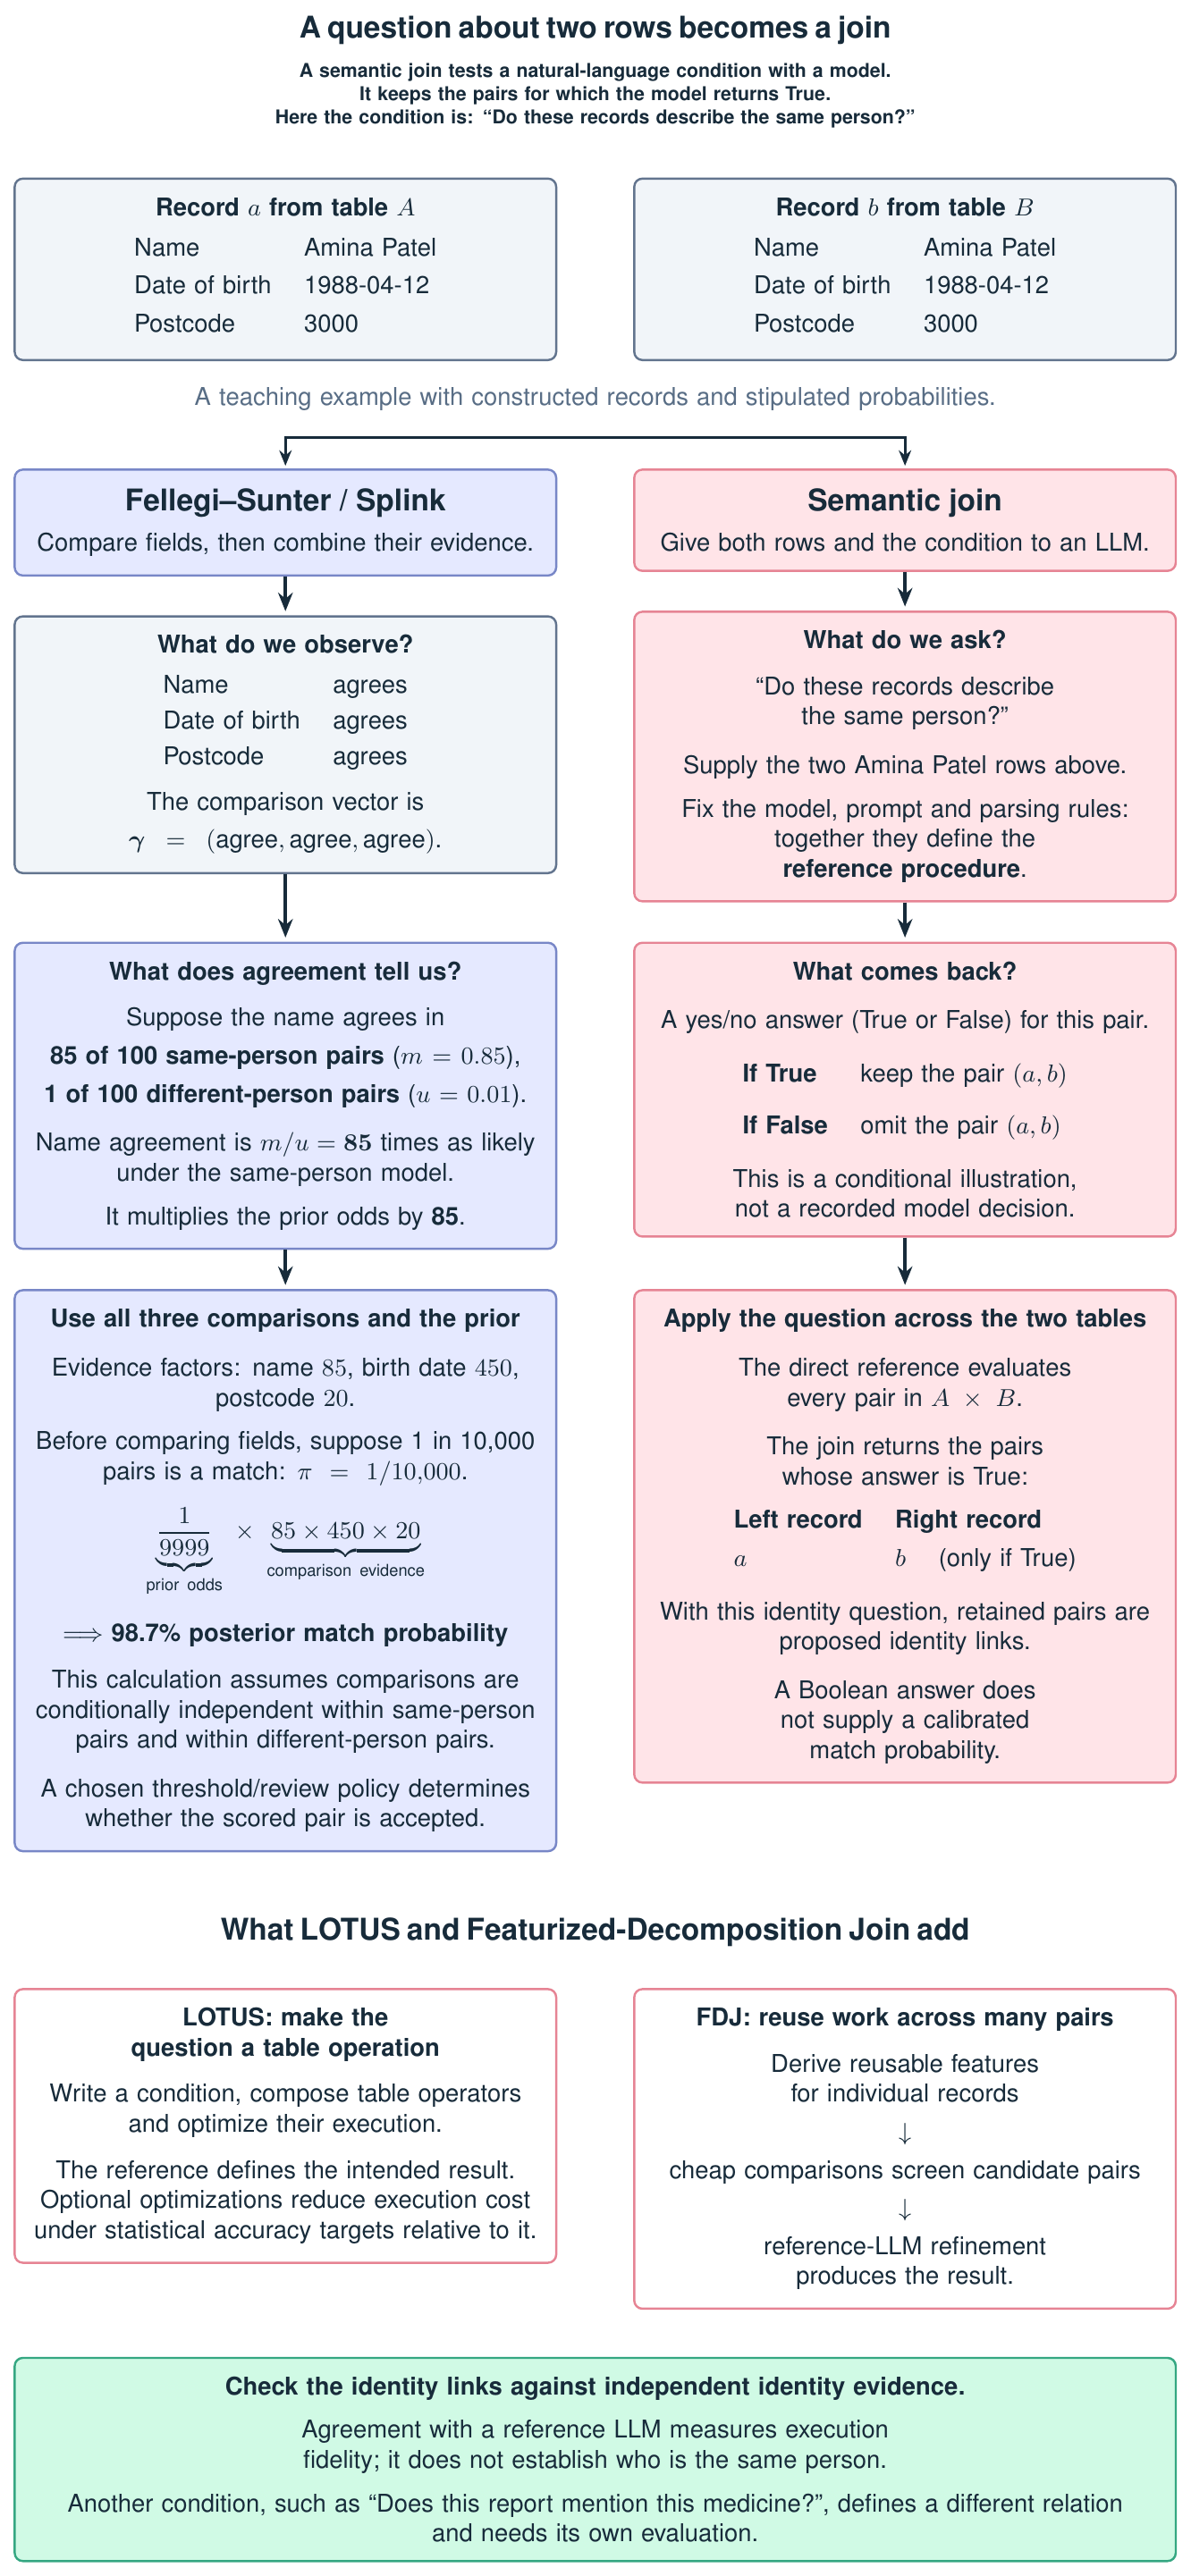

**Overview. Two ways to answer the same question about two records.** The constructed example shows the field evidence. The semantic join uses a written condition and a specified language-model procedure. The lower panels show LOTUS’s operator interface and FDJ’s optimization with reusable features. The LLM return is conditional; this is not a new model run. Sources: [Fellegi–Sunter](https://doi.org/10.1080/01621459.1969.10501049), [Patel et al., LOTUS §§2.2–2.4](https://www.vldb.org/pvldb/vol18/p4171-patel.pdf#page=3) and [Zeighami, Shankar and Parameswaran, FDJ §§2–3](https://arxiv.org/html/2512.05399v1#S2). [Full-size PDF](record-linkage-tutorial/diagrams/11-linkage-semantic-overview.pdf).

### Operators, execution and the target of accuracy

Patel et al. define the operator directly:

> A semantic operator is a declarative transformation over one or more datasets, parameterized by a natural language expression.

[LOTUS, §2.2](https://www.vldb.org/pvldb/vol18/p4171-patel.pdf#page=3). `sem_filter` tests a row, `sem_join` tests pairs, `sem_map` derives a value per row, and `sem_agg` combines rows. The operator expresses the relation; its reference algorithm specifies the model procedure. [LOTUS, §§2.2–2.4](https://www.vldb.org/pvldb/vol18/p4171-patel.pdf#page=3).

```python
reports.sem_join(categories,
    "The report {text:left} describes the reaction {reaction:right}.")
```

Zeighami, Shankar and Parameswaran define the join directly:

> A semantic join between two tables applies a user-specified natural language filter to their cross product using a Large Language Model (LLM).

[FDJ, §1](https://arxiv.org/html/2512.05399v1#S1). The reference join evaluates every pair. Optimizations such as retrieval, cascades or reusable features aim to reduce work while reproducing that reference within a stated tolerance. Featurized-Decomposition Join (**FDJ**) formalizes precision and recall against the reference model's accepted set. That set can differ from independently established truth. [FDJ, §2](https://arxiv.org/html/2512.05399v1#S2).

**Illustration:** a copy of a fallible reference can agree on all four pairs (100%) while agreeing with identity truth on only two (50%). Both quantities matter when evaluating an optimization. The direct LOTUS experiments below measure labeled task agreement; they do not measure optimizer speedups. Operator-level guarantees also do not establish the reliability of a composed pipeline.

The NSO candidate selectors later in this report are custom provider-API implementations. The person, BioDEX and FEVER examples use native LOTUS operators; the three-office demonstration uses native `Corpus.agent`. The experiments test particular implementations, not interchangeably “LOTUS performance.”

In [2]:
reference_pairs, reference_scores = reference_example()
display(reference_pairs)
display(reference_scores.to_frame("agreement").style.format(format_percent))

,entity truth,reference decision,reference copy
pair,,,
a,True,True,True
b,False,True,True
c,True,False,False
d,False,False,False


,agreement
Agreement with reference,100%
Accuracy against entity truth,50%


<a id="scoring"></a>
## 2. Combine identity evidence and understand the fit

Fellegi–Sunter linkage compares fields such as name, date of birth and postcode. For comparison outcome $\gamma_k$, define $m_k=P(\gamma_k\mid M)$ among matches and $u_k=P(\gamma_k\mid U)$ among nonmatches. Under conditional independence of those comparisons within each group,

$$\text{posterior odds}=\text{prior odds}\prod_k\frac{m_k}{u_k},\qquad
W=\log_2\frac{\pi}{1-\pi}+\sum_k\log_2\frac{m_k}{u_k}.$$

Here $\pi$ is the prior match probability and $W$ is the evidence score in bits; the calculated match probability is $1/(1+2^{-W})$. Rare agreement can add more evidence than common agreement. Contradiction can subtract evidence. The independence assumption, prior and fitted frequencies all affect the result. [Fellegi and Sunter (1969)](https://doi.org/10.1080/01621459.1969.10501049).

**Illustration:** keep name and postcode evidence fixed, then change birth-date agreement to contradiction. The model below calculates a drop from 98.7% to 0.4%; these stipulated probabilities are not measured accuracy.

In [3]:
levels, example_scores = evidence_example(prior=0.0001)
display(levels.style.format({
    "m": format_percent, "u": format_percent,
    "likelihood ratio": lambda x: f"×{x:,.0f}" if x >= 1 else f"÷{1 / x:,.0f}",
    "weight (bits)": "{:+.1f}",
}))
display(example_scores.style.format({
    "prior probability": format_percent,
    "sum of weights (bits)": "{:.1f}",
    "posterior probability": format_percent,
}))

,m,u,likelihood ratio,weight (bits)
comparison outcome,,,,
Name agreement,85%,1%,×85,+6.4
Birth-date agreement,90%,0.2%,×450,+8.8
Birth-date contradiction,2%,90%,÷45,-5.5
Postcode agreement,60%,3%,×20,+4.3


,prior probability,sum of weights (bits),posterior probability
comparison pattern,,,
Three agreements,0.01%,19.5,98.7%
Birth date contradicts,0.01%,5.2,0.4%


### Expectation–maximization uses unlabeled pairs

**Expectation–maximization (EM)** alternates two steps. First, current parameters assign each training pair a match probability. Second, those probabilities weight comparison-category counts used to update the parameters. Repeat until the specified change tolerance or iteration limit is reached.

A pair with match probability 80% contributes 0.8 to match counts and 0.2 to nonmatch counts. For observed outcomes **agree, agree, disagree** with probabilities **0.8, 0.6, 0.1**, the next agreement frequency among matches is `(0.8 + 0.6) / (0.8 + 0.6 + 0.1) = 93.3%`. This is a fractional-count illustration, with the nonmatch frequencies held fixed.

Splink ordinarily estimates nonmatch frequencies from mostly nonmatching random pairs before EM. Training blocks retain pairs satisfying a rule. A field forced to agree by a block cannot be learned in that pass; multiple blocks permit estimation of different fields. Session match fractions can update while the separately supplied overall prior stays fixed. Convergence confirms numerical stopping, not calibration or correct identities. [Splink training rationale](https://moj-analytical-services.github.io/splink/topic_guides/training/training_rationale.html).

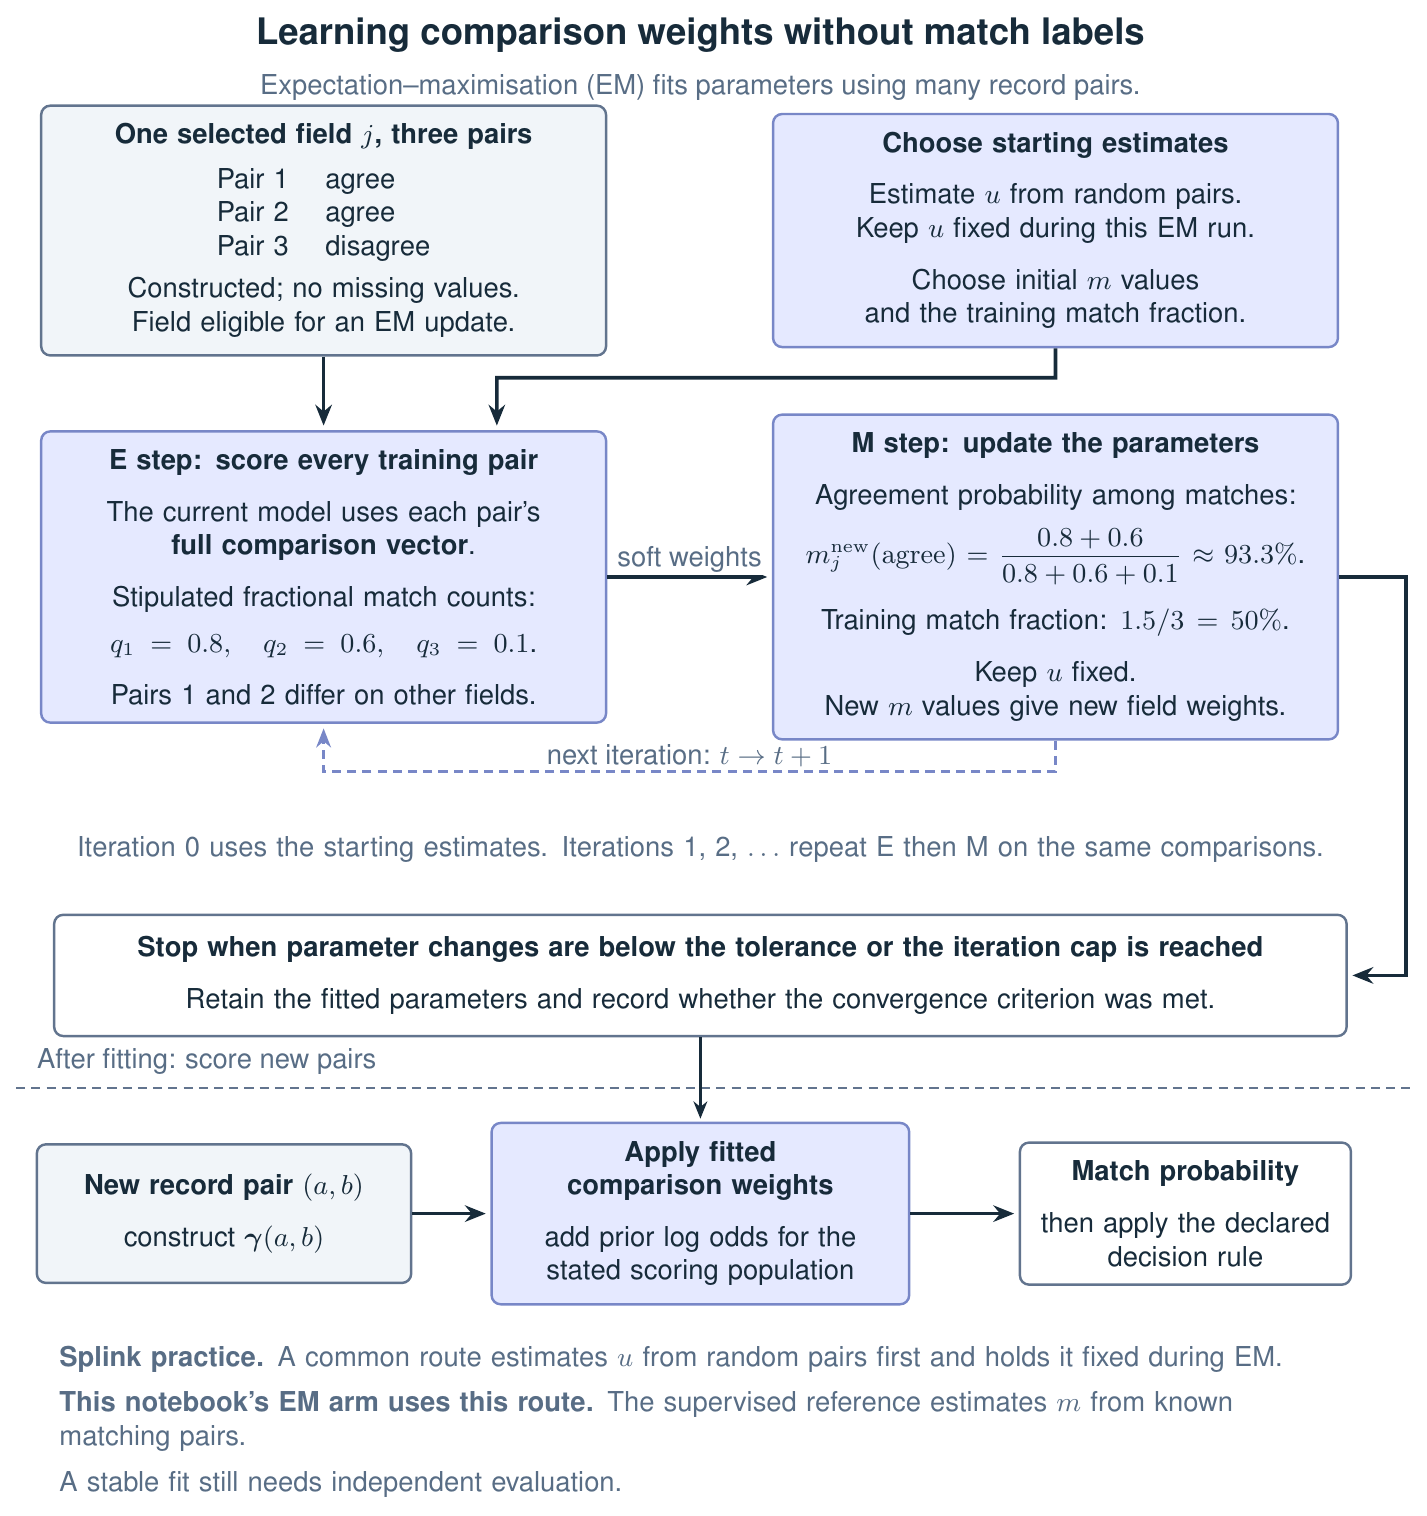

[Full-size PDF](record-linkage-tutorial/diagrams/14-em-learning.pdf)

In [4]:
diagram("14-em-learning")

### Additional evidence must add information

In the next calculation, counting the same signal twice changes a calculated probability from 8.3% to 45% without new information. A language model reading the same names and dates as Splink can reuse those signals even without exact duplication.

[Ather's LLM-assisted record-linkage framework (2026)](https://doi.org/10.1177/18747655261422068) combines classical evidence and selective LLM review using estimated error rates and an explicit dependence simplification. Any extension should estimate additional information on the population actually routed for review. Rates from easy random pairs may misrepresent ambiguous selected pairs. This report's direct joins do not implement or evaluate that hybrid.

In [5]:
display(duplicated_evidence_example().style.format({"posterior probability": format_percent}))

,posterior probability
calculation,
Signal counted once,8.3%
Exact copy incorrectly counted independently,45%


<a id="person"></a>
## 3. Structured person linkage: the conventional baseline already succeeds

**Measured — synthetic FEBRL4 records.** The original synthetic source has 5,000 records per file. The teaching slice selects 15 per side: ten paired identities plus five records per side with no counterpart in the slice, producing 225 pairs and ten true links. Every method sees the same six fields: given name, surname, birth date, synthetic social security ID, street number and postcode. Entity groups stay within one split. Labels score predictions after decisions; they are not input text.

| Procedure | How it is fitted and decides |
|---|---|
| Supervised Splink | Training match labels estimate match frequencies; a separate validation set selects the threshold |
| Unlabeled Splink | 6,972 training records; one million random pairs estimate nonmatch frequencies; EM blocks on birth date and postcode; fixed 50% decision threshold |
| Direct LOTUS join | Same-person language predicate, GPT-6 Luna, 225 Boolean decisions; no task-specific fitting |

The unlabeled prior uses 3,313 pairs selected by strict rules and assumes 80% rule recall. That implies about 4,141 matches, exceeding the one-to-one training maximum of 3,486. Near-perfect rule precision and 80% recall cannot both hold here. The frozen procedure and decisions are preserved, with no claim that these probabilities are calibrated. Both EM passes stopped after three iterations; decisions were stable at the declared 10%, 50%, 90% and 99% thresholds.

This is a previously inspected, enriched teaching slice. It compares complete procedures; changing fitting, prior and threshold together does not isolate the causal effect of removing training labels. [Source and split](record-linkage-tutorial/data/README.md) · [Saved fit and checks](record-linkage-tutorial/README.md#inspect-the-evidence).

In [6]:
from IPython.utils.capture import capture_output
with capture_output():
    DATA = SUPPORT / "data"
    manifest = json.loads((DATA / "manifest.json").read_text())
    for filename, expected in manifest["output_sha256"].items():
        actual = hashlib.sha256((DATA / filename).read_bytes()).hexdigest()
        if actual != expected:
            raise ValueError(f"Prepared file changed: {filename}")

    records = pd.read_csv(DATA / "records.csv", dtype=str)
    truth = pd.read_csv(DATA / "record_truth.csv", dtype=str)
    assert "entity_id" not in records and "rec_id" not in records
    assert records.unique_id.is_unique and truth.unique_id.is_unique
    assert truth.groupby("entity_id").split.nunique().eq(1).all()
    counts = truth.groupby("split").agg(records=("unique_id", "size"),
        entities=("entity_id", "nunique"))
    display(counts)
    record_preview = records.drop(columns=["source", "unique_id"]).head(3).T
    record_preview.columns = ["Example record 1", "Example record 2", "Example record 3"]
    record_preview.index.name = "observed field"
    display(record_preview)

    FIELDS = ["given_name", "surname", "date_of_birth", "soc_sec_id",
              "street_number", "postcode"]
    observed = records[["source", "unique_id"] + FIELDS].copy()
    training = observed.merge(truth.loc[truth.split.eq("train"),
        ["unique_id", "entity_id"]], on="unique_id", validate="one_to_one")

    def load_slice(filename):
        ids = pd.read_csv(DATA / filename, dtype=str)
        selected = ids.merge(observed, on=["unique_id", "source"], validate="one_to_one")
        return tuple(selected.loc[selected.source.eq(source)].reset_index(drop=True)
                     for source in ["febrl4a", "febrl4b"])

    validation_left, validation_right = load_slice("validation_slice.csv")
    left, right = load_slice("evaluation_slice.csv")
    assert len(left) * len(right) == MAX_LIVE_PAIRS
    assert set(training.unique_id).isdisjoint(set(left.unique_id) | set(right.unique_id))
    display(pd.DataFrame({"stage": ["validation", "test"],
        "left rows": [len(validation_left), len(left)],
        "right rows": [len(validation_right), len(right)],
        "pairs": [len(validation_left) * len(validation_right), len(left) * len(right)]}))

    db = DuckDBAPI()
    train_tables = [db.register(part, dataset_display_name=f"train_{source}")
                    for source, part in training.groupby("source")]
    settings = SettingsCreator(
        link_type="link_only", source_dataset_column_name="source",
        probability_two_random_records_match=1 / training.entity_id.nunique(),
        comparisons=[
            cl.NameComparison("given_name").configure(term_frequency_adjustments=True),
            cl.NameComparison("surname").configure(term_frequency_adjustments=True),
            cl.DateOfBirthComparison("date_of_birth", input_is_string=True,
                datetime_format="%Y%m%d", invalid_dates_as_null=True),
            cl.DamerauLevenshteinAtThresholds("soc_sec_id", [1, 2]),
            cl.ExactMatch("street_number").configure(term_frequency_adjustments=True),
            cl.DamerauLevenshteinAtThresholds("postcode", [1, 2]).configure(
                term_frequency_adjustments=True),
        ],
        blocking_rules_to_generate_predictions=["1=1"],
        retain_intermediate_calculation_columns=True,
    )
    linker = Linker(train_tables, settings, log_level="ERROR")
    started = perf_counter()
    linker.training.estimate_u_using_random_sampling(
        max_pairs=1_000_000, seed=2026, min_count_per_level=None, num_chunks=1)
    linker.training.estimate_m_from_label_column("entity_id")
    fit_seconds = perf_counter() - started
    print(f"Splink fitted on {len(training):,} records in {fit_seconds:.2f} seconds.")

    def score_with_splink(a, b, tag):
        tables = [db.register(frame, dataset_display_name=f"{tag}_{i}")
                  for i, frame in enumerate([a, b])]
        predictions = linker.inference.predict_between(*tables,
            blocking_rules_to_generate_predictions=["1=1"]).as_pandas_dataframe()
        predictions = predictions.rename(columns={"unique_id_l": "left_id", "unique_id_r": "right_id"})
        if len(predictions) != len(a) * len(b) or predictions.duplicated(["left_id", "right_id"]).any():
            raise ValueError("Splink did not score the full pair universe exactly once.")
        if not np.isfinite(predictions.match_probability).all():
            raise ValueError("Splink returned an invalid probability.")
        return predictions[["left_id", "right_id", "match_probability"]]

    validation = label_pairs(score_with_splink(validation_left, validation_right, "validation"), truth)
    threshold_table = select_threshold(validation)
    THRESHOLD = float(threshold_table.iloc[0].threshold)
    print(f"Validation-selected threshold: {format_percent(THRESHOLD)} (maximum F1 on the preset grid; ties choose the higher grid threshold)")
    display(threshold_table.head(3).style.format({
        "threshold": format_percent, "precision": format_percent, "recall": format_percent, "F1": format_percent,
        **{c: "{:,.0f}" for c in ["TP", "FP", "FN", "TN", "pairs"]},
    }))
    started = perf_counter()
    splink_scores = score_with_splink(left, right, "test")
    splink_score_seconds = perf_counter() - started

    from unlabeled_benchmark import load_unlabeled_result

    unlabeled_run = load_unlabeled_result(
        SUPPORT / "results/unlabeled-febrl4-20261006T190913831251Z.json", support=SUPPORT)
    em_scores = pd.DataFrame(unlabeled_run["predictions"])[
        ["left_id", "right_id", "match_probability"]].rename(
            columns={"match_probability": "em_probability"})
    EM_THRESHOLD = unlabeled_run["protocol"]["prediction"]["main_threshold"]
    em_training = unlabeled_run["training"]
    em_summary = pd.DataFrame([
        {"training block": s["block_field"].replace("_", " "),
         "pairs in block": s["training_pairs"], "iterations": s["iterations"],
         "stopping tolerance met": "Yes" if s["convergence_criterion_met"] else "No"}
        for s in em_training["em_sessions"]
    ])
    display(em_summary.set_index("training block"))
    print("Every nonmissing comparison level has fitted m and u values:",
          em_training["coverage"]["all_nonnull_levels_estimated"])
    print("Decision threshold:", format_percent(EM_THRESHOLD), "(fixed before fitting)")

    semantic_left = as_semantic_records(left, FIELDS)
    semantic_right = as_semantic_records(right, FIELDS)
    PREDICATE = (
        "The person in {record:left} and the person in {record:right} are the same individual. "
        "Use only the supplied fields. Allow plausible typos and missing values; missingness is not agreement. "
        "Weigh agreement and contradiction across fields. A shared name or address component alone is insufficient. "
        "There may be no matching person in the other table. Evaluate this pair independently."
    )
    spec = run_spec(semantic_left, semantic_right, PREDICATE, MODEL)
    print(semantic_left.record.iloc[0])
    print("\nIdentity predicate:\n" + PREDICATE)

    if RUN_LIVE:
        if not os.environ.get("OPENAI_API_KEY"):
            raise RuntimeError("Set OPENAI_API_KEY in your environment before a live run.")
        if len(semantic_left) * len(semantic_right) > MAX_LIVE_PAIRS:
            raise ValueError("Pair count exceeds this tutorial's live-call limit.")
        preflight = preflight_cost(spec, budget_usd=0.10)
        lm = AuditedLM(model=MODEL, temperature=0, max_tokens=32, max_batch_size=8,
                       reasoning_effort="none", num_retries=0)
        lotus.settings.configure(lm=lm, enable_cache=False)
        started = perf_counter()
        joined = semantic_left.sem_join(semantic_right, PREDICATE)
        run_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
        live_snapshot_path = SNAPSHOT.with_name(f"lotus-febrl4-{run_stamp}.json")
        snapshot = save_snapshot(live_snapshot_path, spec, lm, joined, perf_counter() - started,
                                 preflight=preflight)
        print("New response snapshot:", live_snapshot_path.name)
        mode = "Live API run; earlier snapshots preserved"
    else:
        snapshot = load_snapshot(SNAPSHOT, spec)
        mode = "Replay of recorded API responses; no model calls this execution"

    lotus_scores = pd.DataFrame(snapshot["pairs"])[["left_id", "right_id", "decision"]]
    print(mode)
    print("Recorded at:", snapshot["recorded_at_utc"])
    print("Model:", snapshot["spec"]["model"])
    print("Complete pair decisions:", len(lotus_scores))

    from quality_control import (make_audit_plan, save_audit_plan, simulate_review,
                                 summarize_audit, save_audit_review, census_metrics)

    # Freeze the audit sample from decisions alone, before joining evaluation truth.
    decisions = pair_grid(left, right)
    for scores in [splink_scores, em_scores, lotus_scores]:
        decisions = decisions.merge(scores, on=["left_id", "right_id"], validate="one_to_one")
    assert len(decisions) == 225
    assert decisions[["match_probability", "em_probability", "decision"]].notna().all().all()
    decisions["splink_match"] = decisions.match_probability >= THRESHOLD
    decisions["em_match"] = decisions.em_probability >= EM_THRESHOLD
    METHODS = {"Supervised Splink": "splink_match", "Unlabeled Splink (EM)": "em_match",
               "LOTUS + GPT-6 Luna": "decision"}
    audit_plan = make_audit_plan(decisions[["left_id", "right_id", *METHODS.values()]],
                                METHODS.values(), rejected_sample_size=50, seed=20261006)
    audit_stem = "febrl4-audit-" + audit_plan["plan_sha256"][:12]
    evaluation = label_pairs(decisions, truth)
    assert evaluation.is_match.sum() == 10
    results = pd.DataFrame({name: metrics(evaluation.is_match, evaluation[column])
                            for name, column in METHODS.items()}).T
    count_columns = ["pairs", "TP", "FP", "FN", "TN"]
    results[count_columns] = results[count_columns].astype(int)
    display(results.style.format({**{c: "{:,.0f}" for c in count_columns},
                                 **{c: format_percent for c in ["precision", "recall", "F1"]}}))
    assert results.loc["Unlabeled Splink (EM)", "TP"] == unlabeled_run["evaluation"]["main"]["metrics"]["TP"]
    print("LOTUS model:", MODEL)

    disagreements = evaluation.loc[evaluation[list(METHODS.values())].nunique(axis=1).gt(1)].copy()
    errors = evaluation.loc[evaluation[list(METHODS.values())].ne(evaluation.is_match, axis=0).any(axis=1)].copy()
    print(f"Disagreements: {len(disagreements)} / {len(evaluation)} pairs; pairs with any error: {len(errors)}")
display(results[["TP", "FP", "FN"]].rename(columns={"TP": "True links found", "FP": "False links", "FN": "True links missed"}))

,True links found,False links,True links missed
Supervised Splink,10,0,0
Unlabeled Splink (EM),10,0,0
LOTUS + GPT-6 Luna,8,0,2


Both Splink procedures find all ten links without false links; GPT-6 Luna finds eight. The following records show every disagreement in this fixed slice. Examples are selected after evaluation to explain the result and do not change the fit.

In [7]:
# Inspect every error without truncating the evidence.
if errors.empty:
    print("All three procedures got every pair right on this slice of 10 true links.")
else:
    record_lookup = observed.set_index("unique_id")
    for pair in errors.itertuples():
        display(Markdown(
            f"**True match: {pair.is_match}.** Supervised Splink: {pair.splink_match} "
            f"({format_percent(pair.match_probability)}); "
            f"EM Splink: {pair.em_match} ({format_percent(pair.em_probability)}); LOTUS: {pair.decision}."))
        display(pd.DataFrame({
            "left record": record_lookup.loc[pair.left_id, FIELDS],
            "right record": record_lookup.loc[pair.right_id, FIELDS],
        }))

**True match: True.** Supervised Splink: True (>99.99%); EM Splink: True (>99.99%); LOTUS: False.

,left record,right record
given_name,daniel,montana
surname,lowe,lowe
date_of_birth,19230424,19230424
soc_sec_id,5226883,5226883
street_number,18,18
postcode,2111,2111


**True match: True.** Supervised Splink: True (99.8%); EM Splink: True (99.9%); LOTUS: False.

,left record,right record
given_name,rhiannon,nichoqlas
surname,bishop,hope
date_of_birth,19080513,19080513
soc_sec_id,6284110,1209261
street_number,39,39
postcode,2037,2037


### Follow an actual pair through the fitted score

The benchmark label says the following two records match. The names **daniel** and **montana** supply negative evidence; agreement on the other five fields outweighs it. Frequency adjustments change the contribution of some exact agreements. The reconstruction below checks the full-precision score against the saved comparison; displayed numbers are rounded.

In [8]:
# Inspect the first known match after evaluation; this does not select or fit the model.
worked_pair = evaluation.loc[evaluation.is_match].iloc[0]
worked_a = left.loc[left.unique_id.eq(worked_pair.left_id)].copy()
worked_b = right.loc[right.unique_id.eq(worked_pair.right_id)].copy()
assert len(worked_a) == len(worked_b) == 1
worked_inputs = [
    db.register(worked_a, dataset_display_name="worked_pair_a"),
    db.register(worked_b, dataset_display_name="worked_pair_b"),
]
worked_predictions = linker.inference.predict_between(
    *worked_inputs, blocking_rules_to_generate_predictions=["1=1"]
).as_pandas_dataframe()
assert len(worked_predictions) == 1
worked_prediction = worked_predictions.iloc[0]
np.testing.assert_allclose(
    worked_prediction.match_probability, worked_pair.match_probability,
    rtol=1e-12, atol=1e-14,
)

# Read the fitted level metadata; these attributes are checked against Splink 5.0.0.
worked_comparisons = {
    comparison.output_column_name: comparison
    for comparison in linker._settings_obj.comparisons
}
worked_rows = []
for field in FIELDS:
    comparison = worked_comparisons[field]
    gamma_code = int(worked_prediction[comparison._gamma_column_name])
    level = next(level for level in comparison.comparison_levels
                 if level.comparison_vector_value == gamma_code)
    weight_columns = comparison._match_weight_columns_to_sum
    worked_rows.append({
        "field": field,
        "record a": worked_a.iloc[0][field],
        "record b": worked_b.iloc[0][field],
        "gamma code": gamma_code,
        "comparison outcome": level.label_for_charts,
        "base evidence (bits)": float(worked_prediction[weight_columns[0]]),
        "frequency adjustment (bits)": sum(
            float(worked_prediction[column]) for column in weight_columns[1:]),
        "total evidence (bits)": sum(
            float(worked_prediction[column]) for column in weight_columns),
    })
worked_evidence = pd.DataFrame(worked_rows).set_index("field")
worked_model = linker.misc.save_model_to_json()  # Return settings; write no file.
worked_prior = worked_model["probability_two_random_records_match"]
worked_prior_weight = np.log2(worked_prior / (1 - worked_prior))
worked_evidence_sum = worked_evidence["total evidence (bits)"].sum()
worked_weight = worked_prior_weight + worked_evidence_sum
np.testing.assert_allclose(worked_weight, worked_prediction.match_weight,
                           rtol=1e-12, atol=1e-12)
np.testing.assert_allclose(1 / (1 + 2.0 ** (-worked_weight)),
                           worked_prediction.match_probability,
                           rtol=1e-12, atol=1e-14)

display(Markdown(
    "**The benchmark identity label says these records match.** "
    "We selected this pair after scoring to explain the calculation. "
    "It does not affect training, threshold selection or the results."
))
# Keep the record view and arithmetic narrow enough to read without horizontal scrolling.
display(worked_evidence[["record a", "record b", "gamma code", "comparison outcome"]])
display(worked_evidence[["base evidence (bits)", "frequency adjustment (bits)",
                         "total evidence (bits)"]].style.format("{:+.1f}"))
display(Markdown(
    f"**Actual comparison vector:** `{tuple(worked_evidence['gamma code'])}` "
    "in the field order shown above.\n\n"
    f"Prior {worked_prior_weight:+.1f} bits + field evidence {worked_evidence_sum:.1f} bits "
    f"gives **W = {worked_weight:.1f} bits**. The model's match probability is "
    f"**{format_percent(worked_prediction.match_probability)}**. "
    f"The validation-selected threshold is **{format_percent(THRESHOLD)}**."
))
print("Decision at the validation-selected threshold:",
      "link" if worked_prediction.match_probability >= THRESHOLD else "nonlink")


**The benchmark identity label says these records match.** We selected this pair after scoring to explain the calculation. It does not affect training, threshold selection or the results.

,record a,record b,gamma code,comparison outcome
field,,,,
given_name,daniel,montana,0,All other comparisons
surname,lowe,lowe,4,Exact match on surname
date_of_birth,19230424,19230424,5,Exact match on date of birth
soc_sec_id,5226883,5226883,3,Exact match on soc_sec_id
street_number,18,18,1,Exact match on street_number
postcode,2111,2111,3,Exact match on postcode


,base evidence (bits),frequency adjustment (bits),total evidence (bits)
field,,,
given_name,-2.6,+0.0,-2.6
surname,+7.6,-0.8,+6.8
date_of_birth,+11.7,+0.0,+11.7
soc_sec_id,+11.8,+0.0,+11.8
street_number,+5.9,-0.1,+5.9
postcode,+9.4,+0.1,+9.5


**Actual comparison vector:** `(0, 4, 5, 3, 1, 3)` in the field order shown above.

Prior -11.8 bits + field evidence 43.0 bits gives **W = 31.3 bits**. The model's match probability is **>99.99%**. The validation-selected threshold is **26%**.

Decision at the validation-selected threshold: link


### Check accepted links and look for missed links

A shared simulated audit reviews all ten pairs accepted by any method and samples 50 of the 215 pairs rejected by all methods. The audit uses only the reviewed truth labels. A separate truth census checks the complete benchmark.

All ten accepted pairs were true. Checking the union also exposed the semantic model's two misses because Splink had accepted them. Zero true links in the sampled rejections still permits **0–13** true links in that rejected group at 95% confidence. This finite-population interval ignores the one-to-one constraint and is conservative here. It describes this slice, not future batches. The full truth census independently confirms zero misses in that group.

An operational recall audit should sample records and search for their counterparts beyond production candidates. Reviewing only accepted pairs estimates a different error quantity.

In [9]:
audited_pairs = simulate_review(audit_plan, evaluation[["left_id", "right_id", "is_match"]])
audit = summarize_audit(audit_plan, audited_pairs)
stratum_names = {"accepted_by_any": "Accepted by at least one procedure",
                 "rejected_by_all": "Rejected by every procedure"}
audit_counts = audit["strata"].copy()
audit_counts["stratum"] = audit_counts.stratum.map(stratum_names)
audit_counts = audit_counts.set_index("stratum")[["population_pairs", "sampled_pairs", "observed_true_pairs"]]
audit_counts.columns = ["pairs in group", "pairs reviewed", "true links found"]
display(audit_counts)

qc = audit["metrics"].rename(index={v: k for k, v in METHODS.items()})
qc_display = pd.DataFrame(index=qc.index)
qc_display["accepted links"] = qc.accepted_pairs
qc_display["false links found"] = qc.false_accepted_pairs
qc_display["estimated missed links"] = qc.estimated_missed_true_pairs.map(lambda x: f"{x:.0f}")
qc_display["95% interval for missed links"] = qc.apply(
    lambda r: f"{r.missed_true_pairs_lower_95:.0f}–{r.missed_true_pairs_upper_95:.0f}", axis=1)
display(qc_display)

# The full truth census is a separate check; the audit estimator receives only reviewed labels.
census = census_metrics(audit_plan, evaluation[["left_id", "right_id", "is_match"]])
census = census.rename(index={v: k for k, v in METHODS.items()})
np.testing.assert_allclose(census.loc[results.index, results.columns].to_numpy(dtype=float),
                           results.to_numpy(dtype=float))
print(f"Reviewed {audit['reviewed_pairs']} of {audit['population_pairs']} pairs.")
print("The separate full-truth check agrees with the three-method result table.")

,pairs in group,pairs reviewed,true links found
stratum,,,
Accepted by at least one procedure,10,10,10
Rejected by every procedure,215,50,0


,accepted links,false links found,estimated missed links,95% interval for missed links
method,,,,
Supervised Splink,10,0,0,0–13
Unlabeled Splink (EM),10,0,0,0–13
LOTUS + GPT-6 Luna,8,0,2,2–15


Reviewed 60 of 225 pairs.
The separate full-truth check agrees with the three-method result table.


<a id="text"></a>
## 4. Representation choices and native-text relations

**Illustrative — same evidence, different representation.** “Northbank Laboratory, formerly Lakeside Research Unit, registration 10482” and “Lakeside Research Unit, registration 10482” contain an alias and shared identifier. Extraction can preserve those facts for inexpensive comparison. A mention of Lakeside as a collaborator would express another relation.

| Intervention | What the model does | Reuse and risk |
|---|---|---|
| Recordwise extraction | Recover source-supported aliases, dates, roles or identifiers | Interpret each record once; one extraction error can affect many pairs |
| Additional comparison | Assess a defined relationship between two records | Add a score or feature; account for dependence on existing fields |
| Pair adjudication | Decide whether a selected candidate satisfies the relation | Uses both records together; work grows with examined pairs |

A fair representation test supplies the same permitted observations and candidates to all arms. The deterministic control below turns all six FEBRL fields into sentences and recovers them exactly. It verifies information preservation, not extraction ability on naturally written documents. The complete extraction-plus-Splink **person-identity** experiment on native text remains unrun; the product extraction experiment later is a different task.

In [10]:
original_fields = {field: None if pd.isna(left.iloc[0][field]) else str(left.iloc[0][field])
                   for field in FIELDS}
prose, recovered_fields = controlled_prose(original_fields)
display(Markdown(prose))
display(pd.DataFrame({"original field": original_fields, "recovered field": recovered_fields}))
assert original_fields == recovered_fields

The given name is "zachary". The surname is "goode". The date of birth is "19900208". The soc sec id is "3817430". The street number is "39". The postcode is "7250".

,original field,recovered field
given_name,zachary,zachary
surname,goode,goode
date_of_birth,19900208,19900208
soc_sec_id,3817430,3817430
street_number,39,39
postcode,7250,7250


### BioDEX: article → reaction category

**Measured — 64 pairs from eight biomedical articles and eight categories, with 11 annotated positives.** The models receive the complete upstream `fulltext_processed` field (1,000–8,000 characters), not the original publication PDF. Training-frequency selection chooses the eight categories; eight hashed test reports are drawn from 23 eligible licensed reports. This is an enriched convenience slice. Literal phrase and word matching are cheap baselines. This is a small adaptation of a paper workload, not a full benchmark replication. [BioDEX](https://arxiv.org/abs/2305.13395) · [Frozen sources, selection and licences](record-linkage-tutorial/data/unstructured/README.md).

The relation asks whether a report describes the reaction. Published annotations may omit a described event; an unannotated accepted pair remains a false positive under the unchanged scoring reference, with clinical correctness unresolved.

<a id="biodex-workflow"></a>
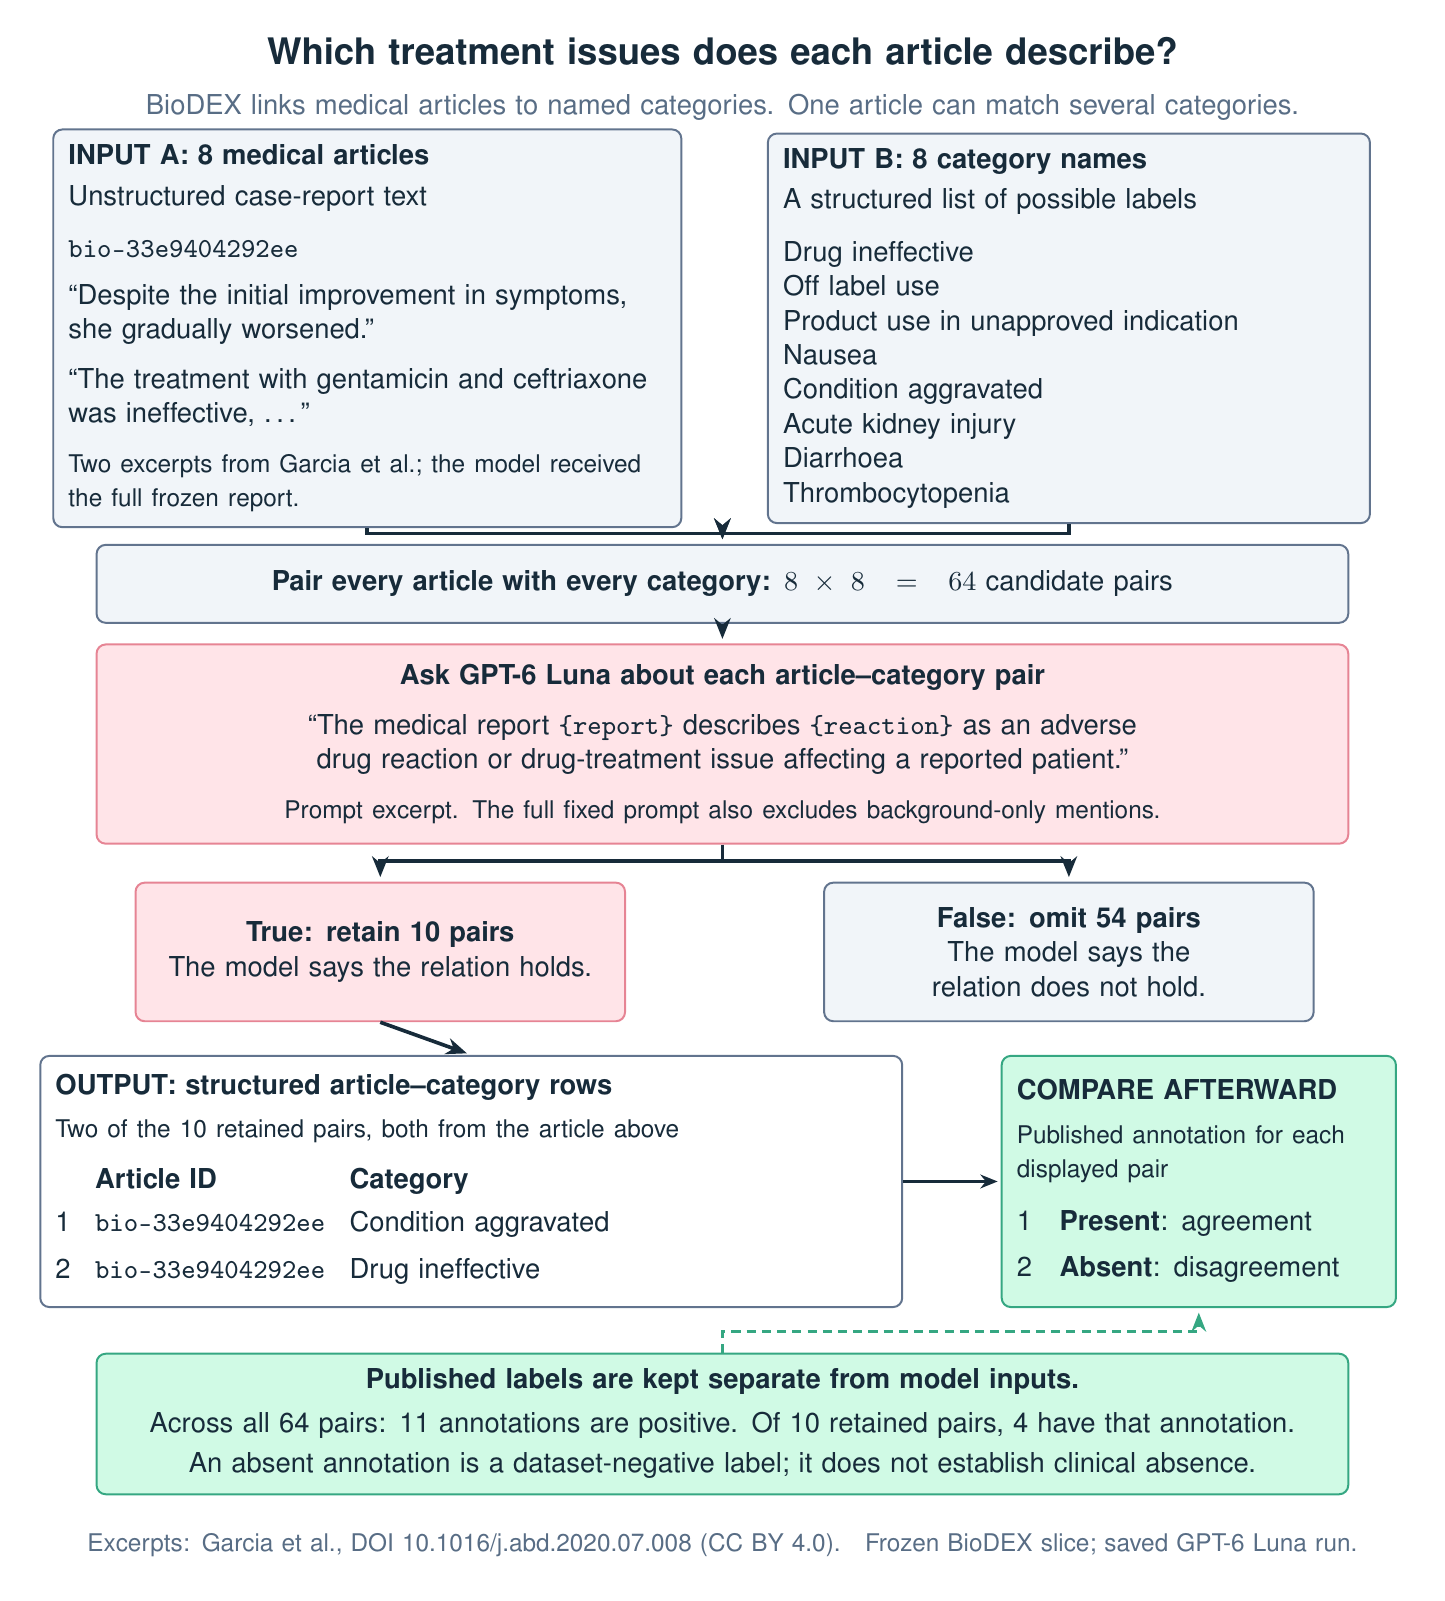

**BioDEX workflow. From medical article text to an article–category relation.** The inputs and output rows come from the saved BioDEX experiment. Model predictions and published reaction annotations are shown separately. Article excerpts: [Garcia et al.](https://doi.org/10.1016/j.abd.2020.07.008), CC BY 4.0; dataset: [BioDEX](https://arxiv.org/abs/2305.13395). [Full-size PDF](record-linkage-tutorial/diagrams/12-biodex-workflow.pdf).

In [11]:
from unstructured_benchmark import load_data, benchmark_tables, run_live
text_data = load_data()
text_paths = run_live(text_data, budget_usd=0.10) if RUN_UNSTRUCTURED_LIVE else None
text_benchmark = benchmark_tables(text_data, snapshot_paths=text_paths)
scores = text_benchmark['metrics'].copy()
scores = scores[['task', 'method', 'pairs', 'TP', 'FP', 'FN', 'TN']]
scores.columns = ['Task', 'Method', 'Pairs', 'True positive', 'False positive', 'False negative', 'True negative']
display(scores.set_index(['Task', 'Method']))

Pairs  True positive  False positive  \
Task   Method                                                            
biodex Literal phrase                64              1               4   
       All label words               64              1               4   
fever  Content-word overlap ≥0.8     12              4               4   
biodex gpt-6-luna                    64              4               6   
       gpt-5.6-luna                  64              6               7   
fever  gpt-6-luna                    12              6               0   
       gpt-5.6-luna                  12              5               0   

                                  False negative  True negative  
Task   Method                                                    
biodex Literal phrase                         10             49  
       All label words                        10             49  
fever  Content-word overlap ≥0.8               2              2  
biodex gpt-6-luna                              7             47  
       gpt-5.6-luna                            5             46  
fever  gpt-6-luna                              0              6  
       gpt-5.6-luna                            1              6

Literal BioDEX matching recovers **one of 11 annotated relations**, versus four for GPT-6 Luna and six for GPT-5.6 Luna. The models also accept six and seven unannotated pairs, respectively, versus four for the literal baseline. Annotation disagreement remains visible; it is not automatically a clinically adjudicated error.

One useful mechanism is the leishmaniasis report's description of treatment producing no response: GPT-5.6 Luna recognizes the annotated “Drug ineffective” relation despite different wording. Both models also accept “Acute kidney injury,” absent from that report's selected annotations, alongside patient-specific laboratory findings. Those acceptances retain their original annotation-based score. [Frozen decisions and source text](record-linkage-tutorial/data/unstructured/README.md).

The FEVER comparison is explained next. On FEVER, GPT-6 Luna agrees with **12/12** labels and GPT-5.6 Luna with **11/12**, versus **6/12** for overlap. This illustrates interpretation after successful retrieval. The claims span nine subjects, exclude insufficient-evidence cases and may be familiar from training. No population accuracy or optimizer speedup follows from the example.

### FEVER: retrieve evidence, then decide whether it supports a claim

**Measured — six supported and six refuted claims across nine subjects.** BM25 lexical retrieval finds the annotated evidence first for all 12 claims in a ten-sentence corpus. The models then receive that annotated passage and page title for support filtering. The overlap baseline accepts when at least 80% of the claim's distinct content words occur in the evidence/title.

A refuting passage can share nearly every word with a claim. The two example rows below show the actual claim, evidence and reference label; the full result table above preserves both models and the baseline. The test excludes insufficient-evidence cases and multi-sentence reasoning. It measures neither open-Wikipedia retrieval nor full FEVER accuracy, and memorization is unresolved. [FEVER source](https://aclanthology.org/N18-1074/).

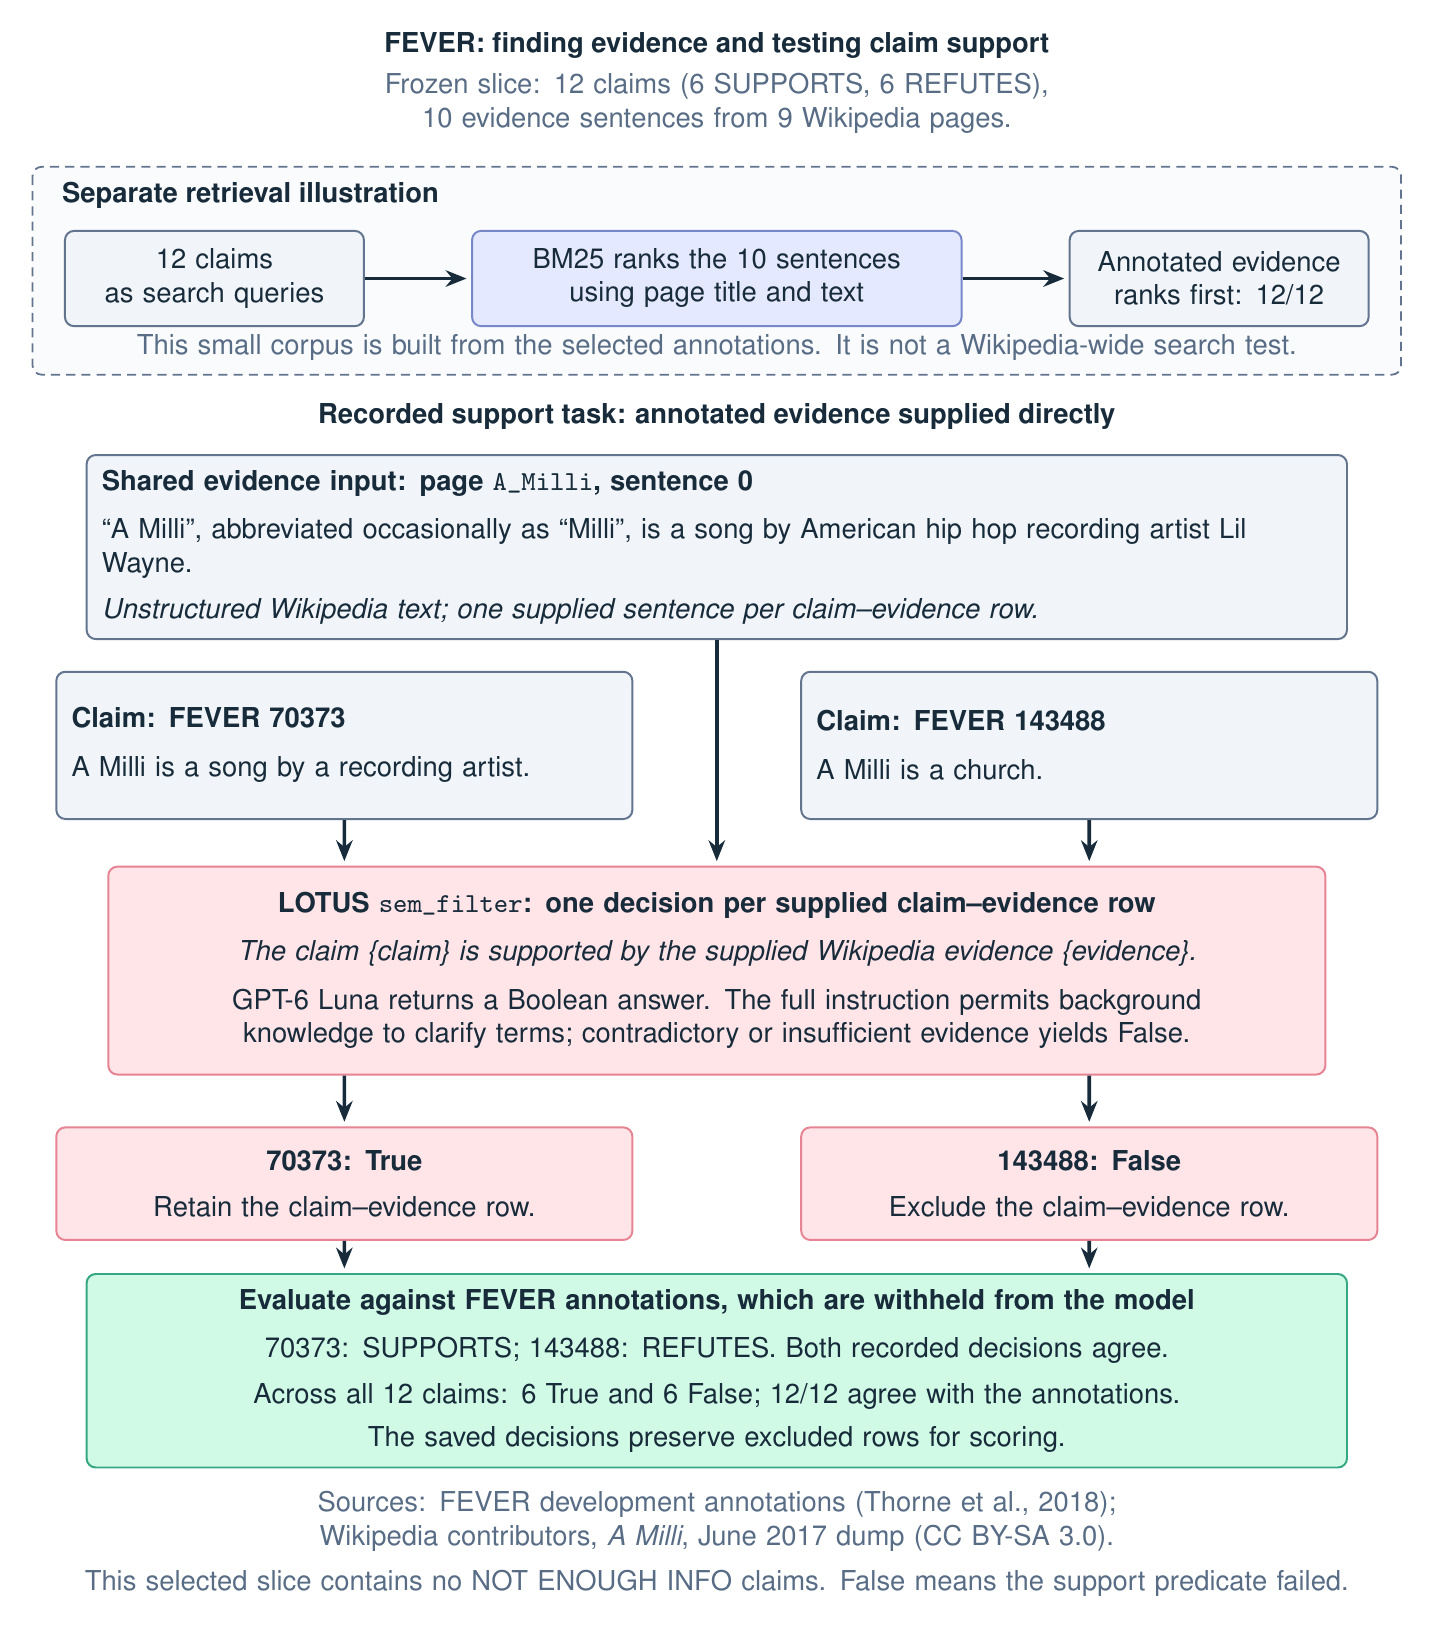

**Actual inputs and saved decisions.** The same passage supports “A Milli is a song” and refutes “A Milli is a church.” The diagram separates the small retrieval illustration from the support filter, which receives annotated evidence directly. [Full-size PDF](record-linkage-tutorial/diagrams/13-fever-workflow.pdf).

In [12]:
fever_examples = text_data["fever_claims"].merge(
    text_data["fever_truth"][["unique_id", "label", "evidence_id"]], on="unique_id",
    validate="one_to_one",
).merge(text_data["fever_evidence"][["unique_id", "title", "sentence"]].rename(
    columns={"unique_id": "evidence_id"}), on="evidence_id", validate="many_to_one")
display(fever_examples.groupby("label", sort=False).head(1)[["claim", "title", "sentence", "label"]].style
    .hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal",
                                        "max-width": "450px"}))

claim,title,sentence,label
Aarhus is the second-largest city in Denmark.,Aarhus,Aarhus -LRB- -LSB- ˈɒːhuːˀs -RSB- ; officially spelled Århus from 1948 until 31 December 2010 -RRB- is the second-largest city in Denmark and the seat of Aarhus municipality .,SUPPORTS
A View to a Kill is a romance movie.,A_View_to_a_Kill,"A View to a Kill -LRB- 1985 -RRB- is the fourteenth spy film of the James Bond series , and the seventh and last to star Roger Moore as the fictional MI6 agent James Bond .",REFUTES


The BioDEX result illustrates recovery of meaning with substantial annotation disagreement. FEVER illustrates a benefit from interpretation once the correct short evidence passage is already available. Neither result establishes an entity-linkage gain, an optimizer speedup or an operational NSO benefit.

In [13]:
from IPython.utils.capture import capture_output
with capture_output():
    from pathlib import Path
    import sys, json, hashlib, contextlib, io
    import pandas as pd
    from IPython.display import display, Markdown, HTML

    ROOT = next(p.resolve() for p in [Path('nso-semantic-workflows'), Path('LLM_basics/nso-semantic-workflows')]
                if (p / 'analyze.py').exists())
    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))
    from verify import verify_ledger
    report = json.loads((ROOT / 'results/analysis/summary.json').read_text())
    assert report['statistics']['status'] == 'complete'
    audit = verify_ledger()
    assert audit['unresolved_attempts'] == 0
    assert audit['attempted_calls'] == report['ledger_snapshot']['attempted_calls']
    for name, expected in report['inputs_sha256'].items():
        assert hashlib.sha256((ROOT/name).read_bytes()).hexdigest() == expected, name

    def table(rows):
        frame = pd.DataFrame(rows)
        styles = ('<style>.jp-RenderedHTMLCommon .nso-table table {font-size:14px; border-collapse:collapse; max-width:100%;} '
                  '.jp-RenderedHTMLCommon .nso-table td,.jp-RenderedHTMLCommon .nso-table th {padding:8px 10px; text-align:left; vertical-align:top; white-space:normal;} '
                  '.jp-RenderedHTMLCommon .nso-table th {border-bottom:1px solid #c7d1db;} </style>')
        display(HTML(styles + '<div class="nso-table">' +
                     frame.to_html(index=False, escape=True, border=0) + '</div>'))

    display(HTML('<style>.jp-RenderedHTMLCommon table {font-size:14px; width:100%;} '
                 '.jp-RenderedHTMLCommon td,.jp-RenderedHTMLCommon th {padding:8px 10px; text-align:left; vertical-align:top; white-space:normal;} '
                 '.jp-RenderedHTMLCommon blockquote {overflow-wrap:anywhere;} </style>'))
    print(f"Verified {audit['attempted_calls']} recorded model calls and complete result inputs; no new calls.")
    import subprocess
    followup_audit = json.loads(subprocess.check_output([sys.executable, str(ROOT / 'adversarial-2026/verify_replay.py')], text=True))
    assert followup_audit['status'] == 'verified'

    FOLLOWUP = ROOT / 'adversarial-2026'
    FOLLOWUP_HASHES = {'products/results/model-development-v1/conventional-primary.json': 'd8a25d37f0a9802d41a995bdcb188b20c06f6d994aa75196c3fe0c08b057772e', 'products/results/model-development-v1/semantic-primary.json': '0bbce3b833cd8e7bf397eb3b68afe02b32ebae66fdfa75693a35af03048b9269', 'images/results/model-development-v1/comparison.json': '8fe51e49767f960d7fdc071b1dafbeea6a0e0baa22d9790dcd48f8379ad76895', 'images/results/free-test-summary.json': '1c1996b638496a45ffce112a3f6d87673e61fd644a4d3b75a4f0e10c3575c6b2', 'organizations/results/development-score.json': 'ed1b2adafa32684484171131752a0acb17a51967a56374d011b30801868919d8'}
    def saved_followup(name):
        raw = (FOLLOWUP / name).read_bytes()
        assert hashlib.sha256(raw).hexdigest() == FOLLOWUP_HASHES[name], name
        return json.loads(raw)

    product_conventional = saved_followup('products/results/model-development-v1/conventional-primary.json')
    product_semantic = saved_followup('products/results/model-development-v1/semantic-primary.json')
    image_development = saved_followup('images/results/model-development-v1/comparison.json')
    image_free_test = saved_followup('images/results/free-test-summary.json')
    organization_development = saved_followup('organizations/results/development-score.json')

    def decision_row(label, s):
        return {'Method': label, 'Correct / total': f"{s['correct_complete_decisions']}/{s['queries']}",
                'Automatic': s['automatic_decisions'], 'False links': s['false_links'],
                'Missed links': s['missed_links'], 'Review': s['review_queries'], 'Failed': s['failed_queries']}

    table([decision_row(label, group[key]['summary']) for label, group, key in [
        ('Lexical, fixed 0.65', product_conventional, 'lexical_all_pairs'),
        ('Splink, fixed 0.9', product_conventional, 'splink_all_pairs'),
        ('Recordwise extraction → Splink', product_semantic, 'extraction_splink_all_pairs'),
        ('Model candidate selection', product_semantic, 'semantic_selection')]])

    from pathlib import Path as _ph_Path
    import json as _ph_json, hashlib as _ph_hashlib
    import pandas as _ph_pd
    from IPython.display import display as _ph_display, Markdown as _ph_Markdown

    _ph_roots = [_ph_Path('nso-semantic-workflows/adversarial-2026'),
                 _ph_Path('LLM_basics/nso-semantic-workflows/adversarial-2026')]
    _ph_root = next(p.resolve() for p in _ph_roots if (p/'products/score_evaluation.py').is_file())
    _ph_output = _ph_root/'products/results/model-evaluation-v1'
    _ph_ready = (_ph_output/'completion.json').is_file()
    assert _ph_ready, 'Missing sealed product evaluation artifacts'
    _PH_COMPLETION_SHA256 = '9c79f59100858df47454bb36f0f47c0d4fef9ab761f03f5ee93833231c194b41'
    _ph_table = globals().get('table', lambda rows: _ph_display(_ph_pd.DataFrame(rows)))

    def _ph_read(path):
        value = _ph_json.loads(path.read_text())
        _ph_json.dumps(value, allow_nan=False)
        return value

    def _ph_hash(path):
        h = _ph_hashlib.sha256()
        with path.open('rb') as handle:
            for chunk in iter(lambda: handle.read(1024*1024), b''):
                h.update(chunk)
        return h.hexdigest()

    def _ph_bound(name):
        path = (_ph_output/name).resolve()
        assert path.is_relative_to(_ph_output), name
        assert name in _ph_completion['files'] and _ph_hash(path) == _ph_completion['files'][name], name
        return _ph_read(path)

    _ph_primary_keys = [
        ('Lexical: all pairs', 'lexical_all_pairs', 'lexical/threshold=0.65/all_pairs'),
        ('FS: all pairs', 'splink_all_pairs', 'splink/assumed_recall=0.8;threshold=0.9/all_pairs'),
        ('Lexical: same candidates', 'lexical_same_candidates', 'lexical/threshold=0.65/same_candidates'),
        ('FS: same candidates', 'splink_same_candidates', 'splink/assumed_recall=0.8;threshold=0.9/same_candidates'),
        ('Semantic selection', 'semantic_selection', 'semantic_selection'),
    ]
    if not _ph_ready:
        _ph_display(_ph_Markdown('**Pending sealed evaluation.** No held-out result is loaded or implied.'))
    else:
        assert _ph_hash(_ph_output/'completion.json') == _PH_COMPLETION_SHA256
        _ph_completion = _ph_read(_ph_output/'completion.json')
        assert _ph_completion['status'] == 'sealed_held_out_tradeoff_scored_once'
        assert _ph_hash(_ph_root/'products/score_evaluation.py') == _ph_completion['evaluator_sha256']
        for _ph_name, _ph_digest in _ph_completion['files'].items():
            _ph_path = (_ph_output/_ph_name).resolve()
            assert _ph_path.is_relative_to(_ph_output) and _ph_hash(_ph_path) == _ph_digest, _ph_name
        _ph_seal_path = _ph_root/'results/product-holdout-v1/prediction-seal.json'
        assert _ph_hash(_ph_seal_path) == _ph_completion['seal_file_sha256']
        _ph_seal = _ph_read(_ph_seal_path)
        assert _ph_seal['status'] == 'predictions_sealed'
        assert _ph_seal['manifest_sha256'] == _ph_completion['manifest_sha256']
        assert _ph_seal['evaluator_sha256'] == _ph_completion['evaluator_sha256']
        _ph_manifest = _ph_read(_ph_root/'contracts/products-tradeoff-test-v1.json')
        _ph_manifest_bytes = _ph_json.dumps(_ph_manifest, ensure_ascii=False, sort_keys=True,
                                          separators=(',', ':'), allow_nan=False).encode()
        assert _ph_hashlib.sha256(_ph_manifest_bytes).hexdigest() == _ph_completion['manifest_sha256']
        _ph_predictions = (_ph_root/_ph_seal['predictions_path']).resolve()
        assert _ph_predictions.is_relative_to(_ph_root)
        assert _ph_hash(_ph_predictions) == _ph_seal['predictions_sha256']
        _ph_summary = _ph_bound('primary-summary.json')
        _ph_all = _ph_bound('all-fixed-rule-summaries.json')
        _ph_paired = _ph_bound('paired-family-uncertainty.json')
        _ph_candidates = _ph_bound('candidate-audit.json')
        _ph_subgroups = _ph_bound('subgroup-summaries.json')
        _ph_loss = _ph_bound('descriptive-loss-grid.json')
        assert _ph_summary['results'] == _ph_completion['primary_summary']
        assert len(_ph_all) == 65 and set(_ph_paired) == set(_ph_all)-{'semantic_selection'}
        assert _ph_summary['queries'] == _ph_seal['query_count'] == _ph_seal['terminal_result_count']
        assert all(v['queries'] == _ph_summary['queries'] for v in _ph_all.values())
        assert len({v['query_denominator_sha256'] for v in _ph_all.values()}) == 1
        _ph_execution = _ph_summary['execution_audit']
        _ph_display(_ph_Markdown(
            f"Verified **{_ph_summary['queries']:,} queries**, **{_ph_summary['catalog_records']:,} catalog records**, "
            f"and **{_ph_summary['source_families']:,} query families**. "
            "The original development gate remains failed; extraction remains development-only."))
        _ph_table([
            {'Execution / cost item':'Provider terminal state', 'Recorded value':_ph_execution['terminal_status']},
            {'Execution / cost item':'Attempts / terminal results', 'Recorded value':f"{_ph_execution['attempted_requests']} / {_ph_execution['terminal_result_count']}"},
            {'Execution / cost item':'Parsed result states', 'Recorded value':str(_ph_execution['parsed_result_status_counts'])},
            {'Execution / cost item':'Decision states', 'Recorded value':str(_ph_execution['decision_status_counts'])},
            {'Execution / cost item':'Returned model identifiers', 'Recorded value':str(_ph_execution['provider_model_id_counts'])},
            {'Execution / cost item':'Reserved USD', 'Recorded value':f"{float(_ph_execution['reserved_usd']):.4f}"},
            {'Execution / cost item':'Known token-price estimate, USD', 'Recorded value':f"{float(_ph_execution['nominal_token_price_usd']):.4f}"},
            {'Execution / cost item':'Unpriced results', 'Recorded value':_ph_execution['unpriced_results']},
        ])
        _ph_display(_ph_Markdown('Token-price estimates are not invoices. Any unpriced results make the known usage sum incomplete.'))

<a id="selection"></a>
## 5. Affiliation matching and classification

### Historical affiliation text → organization: a candidate NSO workflow

**Measured — the strongest positive real-text selection result in this portfolio.** S2AFF supplies 644 historical affiliation strings with annotated Research Organization Registry (**ROR**) identifiers. Retrieval searches 102,742 entries from the recorded 2022 registry; GPT-6 Luna selects from 25 candidates. The original lexical rule combines names, aliases and location evidence with thresholds selected on 100 validation records. [Pinned source](https://github.com/allenai/S2AFF/tree/ac8d6b58f42b253821c26fff8b013913317c5c72) · [Original protocol](nso-semantic-workflows/protocol-linkage.md).

The original result remains **456 → 593/644** valid annotated sets, with 152 corrections and 15 regressions against lexical matching. Extra target IDs relative to the annotations fall from 174 to 30. The following table adds two newly trained conventional methods; the tree was selected on validation before test scoring. “Exact” includes valid review-flagged proposals. In the automatic column, correct and wrong refer to resolved decisions; unresolved combines reviews and invalid responses. Each row retains all 644 inputs.

**Statistical use.** This relation could attach research outputs to organizations for institutional statistics. The workflow returns source text, proposed registry IDs and unresolved cases. Historical ROR organizations are the measured units here; transfer to a business register requires that register’s unit definitions and independent labels. Staff-time savings have not been measured.

In [14]:
VALUE = ROOT / 'affiliation-value'
VALUE_HASHES = {'results/evaluation.json': '4ec843719eb3eefd9e6dfcadae614ca4570e606c04455e2e03a9a1a638421194', 'results/validation-selection.json': 'f6cb750bee8cf44576eea8f49fef8c0d6e354a55294a040fa94a0a8981c4f45a', 'results/test-predictions.json': 'cef3bd2442b61ef6036dc22fb98ccd7b81c1e9098fb6c4848675d7845f1fddae'}
def saved_value(name):
    raw = (VALUE / name).read_bytes()
    assert hashlib.sha256(raw).hexdigest() == VALUE_HASHES[name], name
    return json.loads(raw)
value = saved_value('results/evaluation.json')
value_selection = saved_value('results/validation-selection.json')
value_predictions = saved_value('results/test-predictions.json')
assert value['primary_model'] == value_selection['primary_model'] == 'hist_gradient_boosting'
value_labels = [('Lexical rule', 'lexical'), ('Trained logistic', 'logistic'),
                ('Trained tree (validation-selected)', 'hist_gradient_boosting'), ('Saved GPT-6 Luna', 'saved_llm')]
value_rows=[]
for label, key in value_labels:
    v=value['scores'][key]['all']
    raw=v['valid_set']; automatic=v['automatic_conditional']
    correct=automatic['exact_sets']; wrong=automatic['rows']-correct
    unresolved=raw['review_rows']+raw['invalid_rows']
    value_rows.append({'Method':label, 'Exact / 644':raw['exact_sets'],
        'Automatic: correct / wrong / unresolved':f"{correct} / {wrong} / {unresolved}"})
table(value_rows)


Method,Exact / 644,Automatic: correct / wrong / unresolved
Lexical rule,456,456 / 188 / 0
Trained logistic,454,454 / 190 / 0
Trained tree (validation-selected),492,492 / 152 / 0
Saved GPT-6 Luna,593,546 / 30 / 68


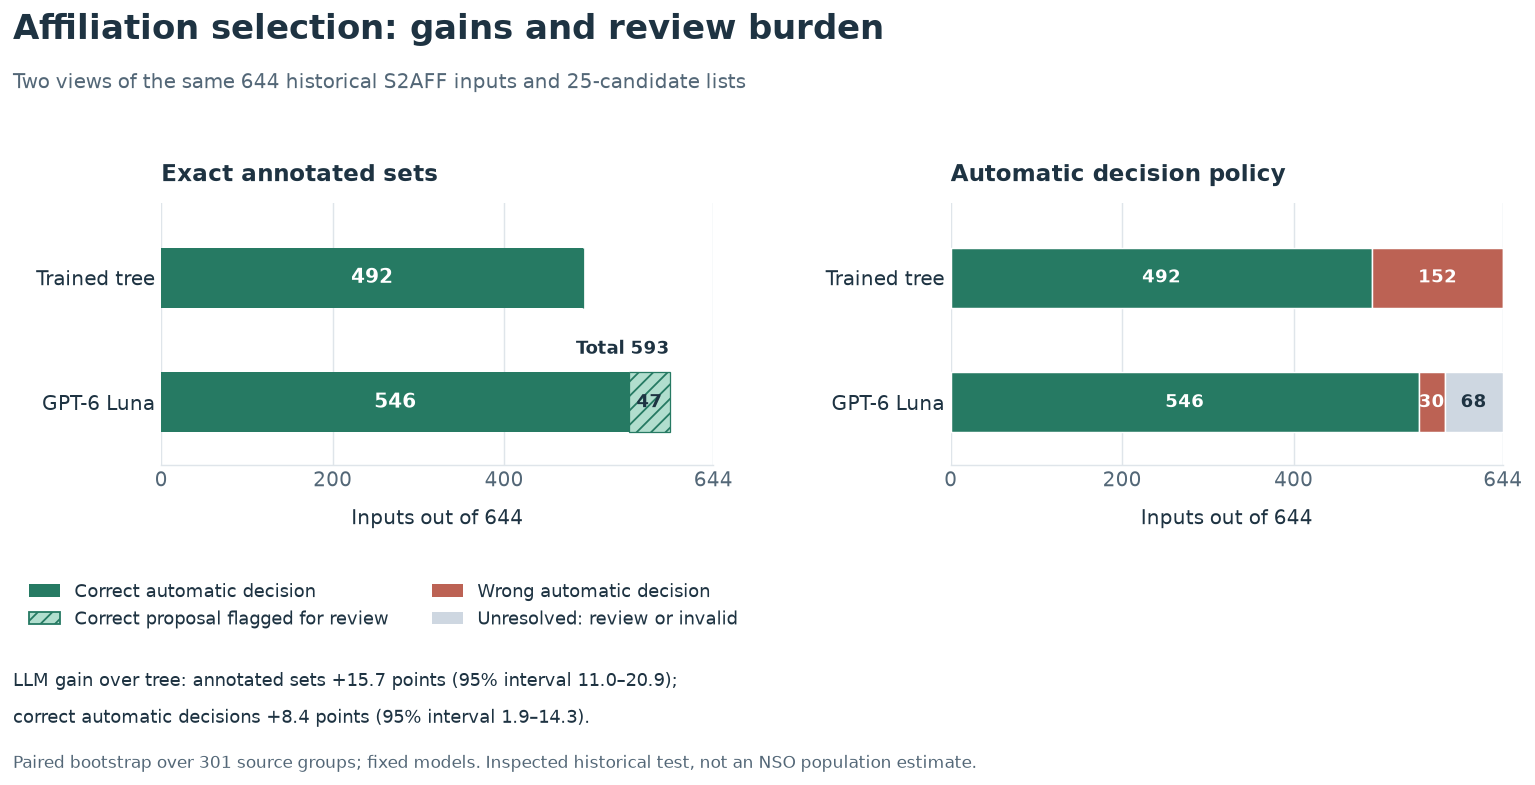

In [15]:
import matplotlib.pyplot as plt
from report_visuals import affiliation_outcomes, product_tradeoff
figure = affiliation_outcomes(ROOT)
display(figure, metadata={"image/png": {"width": 1000}})
plt.close(figure)

**Affiliation decisions, all 644 inputs.** The LLM’s 593 valid annotated sets combine 546 correct automatic decisions and 47 correct proposals awaiting review. Its automatic policy leaves 68 unresolved and returns 30 incorrect decisions. Each outcome is reconstructed from the frozen predictions; the chart does not treat review as acceptance.

### Does training a conventional matcher close the gap?

**Measured — a retrospective comparison on the same public test.** Two fixed models use 32 features from character/word similarity, aliases, abbreviations, geography and candidate ranks. They fit **1,127 retained training rows** after removing five training rows whose normalized text also appears in validation or test. Model and set threshold are selected on all **588 validation rows**: the boosted tree scores 436/588 at threshold 0.95, versus logistic regression's 393/588 at 0.925. These scores are not calibrated probabilities. The original 644 test candidate lists are reused exactly; missing targets are never inserted. Predictions were sealed before this extension's test scoring. [Protocol, code and complete results](nso-semantic-workflows/affiliation-value/README.md).

The trained tree improves **456 → 492** sets and reduces extra IDs **174 → 51**. The LLM still makes **118 corrections and 17 regressions** against it: **+101 sets, or 15.7 percentage points**. A paired bootstrap over 301 groups connected by shared organizations, normalized text or historical non-ROR labels gives a 95% pointwise percentile interval of **11.0–20.9 points**. This resamples the historical benchmark; it is not an NSO population interval or an estimate of model-fitting uncertainty. The separate logistic result remains in the table, including its lower score.

This comparison uses more validation labels than the original lexical rule and keeps the original LLM decisions fixed. The test was already inspected before this extension; four test rows also share normalized text with validation. Omitting only those four rows from reporting leaves **491 → 591/640**, a 15.6-point difference, without retraining. This evaluates two specified conventional learners under common candidate availability. The official S2AFF NER/retrieval/reranking pipeline has not been run.

**Where the gain occurs.** Single-ID rows supply 94 of the 101 additional exact sets. For automatic decisions, the LLM produces **541 correct singleton decisions** versus the tree's **461**, but **zero correct automatic no-target decisions** versus **29**. The LLM flags all 32 of its correct no-target proposals for review. Its full automatic policy has 29 extra IDs and 44 missed reference IDs, versus the tree's 51 and 126; review and failure cases stay in the denominator. These observed operating points support contextual positive selection and expose the unresolved rejection/review policy; they do not define a required operational error allowance.

In [16]:
table([{'Reference group (rows)':f"{label} ({value['group_sizes'][key]})",
        'Trained tree: exact':value['scores'][value['primary_model']][key]['valid_set']['exact_sets'],
        'LLM: valid exact':value['scores']['saved_llm'][key]['valid_set']['exact_sets']}
       for key,label in [('single','One ID'),('nil','No ROR ID'),
                         ('multi','Several IDs'),('all','All inputs')]])

Reference group (rows),Trained tree: exact,LLM: valid exact
One ID (590),461,555
No ROR ID (38),29,32
Several IDs (16),2,6
All inputs (644),492,593


<a id="dataset-showcase"></a>
The 593 valid agreements include **47 correct selections flagged for review**. Sixty-five outputs request review and three fail task validation; 30 of 576 automatic outputs disagree with the recorded sets. All six automatically decided rows whose reference has no target were falsely linked. Of 606 positive rows, **597 have all targets in the candidates**; nine cannot be solved completely by selection alone. Historical public-organization labels may have been encountered in model training and do not define NSO business-register units.

**Label meaning.** Exact label-set agreement requires the returned ROR IDs to equal the recorded IDs. Multiple-ID rows include both strings naming several organizations and ambiguous short strings such as “IEEE.” The [source evaluator](https://github.com/allenai/S2AFF/blob/ac8d6b58f42b253821c26fff8b013913317c5c72/scripts/train_lightgbm_reranker.py) scores ranked positives; it does not establish that every multi-label row requires simultaneous assignment to all recorded organizations. We preserve the original set score and report label-cardinality groups separately.

The original first correction and automatic label-set disagreement by case ID remain below, now with the trained comparator. A third example shows a company/university ambiguity that both trained models retain and the LLM resolves. These selected examples illustrate decisions; the full test determines the reported gain.

Reference disagreements also need inspection. In `s2aff-0482`, the source explicitly names Cambridge **and** Regina, but the historical label records Cambridge alone. The trained tree matches that label; the LLM selects both named universities. This is a reference-policy question, not sufficient evidence of an unrelated invented organization. An exploratory [source-consistency check](nso-semantic-workflows/affiliation-value/results/source-consistency-audit.json) finds explicitly named extra organizations in 12 of the 17 cases where the trained tree matches the labels and the LLM does not. This scoped check is not label adjudication, and all original scores remain unchanged.

In [17]:
import html
ror_names={x['id']:x['name'] for x in json.loads((ROOT/'data/linkage/s2aff-candidate-registry.json').read_text())}
affiliation_cases={x['id']:x for x in json.loads((ROOT/'results/analysis/linkage-test-cases.json').read_text())}
def target_names(items):
    return '; '.join(x.get('name') or x['id'] for x in items) or 'No target'
def trained_names(key,case_id):
    return '; '.join(ror_names[t] for t in value_predictions['arms'][key][case_id]) or 'No target'
example_specs=[(report['linkage']['test']['examples']['corrected']['id'],'Original first correction'),
               (report['linkage']['test']['examples']['wrong_automatic']['id'],'Original first automatic label-set disagreement'),
               ('s2aff-0138','University versus company ambiguity')]
for case_id,label in example_specs:
    x=affiliation_cases[case_id]
    display(HTML(f"<p><b>{label} — {case_id}</b></p><blockquote>{html.escape(x['text'])}</blockquote>"))
    table([{'Method / reference':method, 'Selected organizations':targets} for method,targets in [
        ('Reference',target_names(x['reference_targets'])), ('Lexical',target_names(x['baseline_targets'])),
        ('Trained logistic',trained_names('logistic',case_id)),
        ('Trained tree',trained_names(value['primary_model'],case_id)),
        ('Saved LLM',target_names(x['model_targets']))]])


Method / reference,Selected organizations
Reference,Xidian University
Lexical,No target
Trained logistic,Xidian University
Trained tree,No target
Saved LLM,Xidian University


Method / reference,Selected organizations
Reference,Peking University
Lexical,Institute for Nuclear Science and Technology
Trained logistic,Peking University
Trained tree,No target
Saved LLM,Peking University; Institute of Software


Method / reference,Selected organizations
Reference,Xidian University
Lexical,China XD Group (China)
Trained logistic,China XD Group (China); Xidian University
Trained tree,China XD Group (China); Xidian University
Saved LLM,Xidian University


### Industry and occupation coding

**Measured — synthetic descriptions against full official codebooks.** Industry uses the North American Industry Classification System (**NAICS**); occupation uses the National Occupational Classification (**NOC**). Retrieval searches 923 industry and 516 occupation entries before selection from the top ten query-derived candidates, without inserting reference targets. Each scheme’s 12 boundary families split into four development and eight test families, with 32 test cases per scheme.

These descriptions were authored by another language model and reviewed by a separate model, without independent human labels. They are deliberate boundary examples, not observed returns or a probability sample. Each test has 24 uniquely codeable cases and eight explicitly incomplete cases requiring review. Forty-eight separate verbatim lookup controls were all correct; they check lookup, not semantic interpretation. [Coding sources and protocol](nso-semantic-workflows/protocol-coding.md).

| Test outcome | Industry | Occupation |
|---|---:|---:|
| Correct complete decisions, lexical → semantic | 18 → 28/32 | 23 → 27/32 |
| Correct unique codes, semantic | 20/24 | 19/24 |
| Correct required reviews, semantic | 8/8 | 8/8 |
| Corrections / regressions | 11 / 1 | 4 / 0 |

The correct code is retrieved for 21/24 uniquely codeable industry cases and 22/24 occupation cases. The occupation test has two task-invalid outputs. An industry regression changes the correct accounting code; an occupation output quotes a source phrase that was never present. These failures distinguish retrieval, interpretation and evidence validation.

The examples distinguish establishment activity from an individual's duties. Explicit missingness is easier than natural ambiguity; correct reviews are counted separately from code assignments.

In [18]:
for scheme,label in [('naics','Establishment activity'),('noc','Individual occupation')]:
    x=report['coding']['test']['schemes'][scheme]['examples']['corrected']
    source=next(e for e in x['source_label']['source_evidence'] if e['code']==x['reference']['code'])
    display(HTML(f"<p><b>{label} — {x['id']}</b></p><blockquote>{html.escape(x['text'])}</blockquote>"))
    table([{'Reference':x['reference']['code'] + ' — ' + source['title'],
            'Lexical selection':x['baseline_prediction']['code'],
            'Model selection':x['raw_prediction']['code']}])

Reference,Lexical selection,Model selection
541940 — Veterinary services,622210,541940


Reference,Lexical selection,Model selection
31103 — Veterinarians,32104,31103


<a id="other-pilot"></a>
## 6. Where further model work stopped

### School continuity

**Measured — NCES public school directories.** Labels mean the same continuing administrative school identifier, with identifier fields hidden from matching. Schools must be open and not reconstituted in both years. The newer candidate directory contains 102,229 records; excluding development districts leaves an eligible evaluation frame of 94,586 schools.

Conventional matching is correct for all **300 probability-sampled records**, triggering the predeclared stop; no school model calls were made. A separate sample of 100 changed-name-and-street schools gives **72 correct top-ranked matches**, with 96 targets in the top ten. That rare stratum has 161 schools in the frame. These populations are not pooled; the enriched result does not overturn the original stop. Three hundred successes do not prove perfect population accuracy. [Source and method](nso-semantic-workflows/protocol-linkage.md).

### Numerical questions over official tables

**Measured — 32 authored questions over Statistics Canada data.** The frozen corpus contains **401,944 observations from 2023–2025**, including 56 suppressed values. Each question reads 1–12 observations, not the entire corpus. Rules, one-shot planning and an iterative controller receive the same four table dictionaries and calculation language. The controller allows at most four model turns and three execution requests.

Each test has 24 answerable questions and eight required-review cases. Each model correctly answers 21/24 and requests review on 8/8. All three systems score **29/32**. One-shot planning corrects three rule errors and introduces three; iteration corrects three one-shot errors and introduces three. Iteration uses **1.85×** the one-shot tokens and returns three wrong answers without review, versus one for one-shot planning. All controller errors reverse subtraction operands: a tool can calculate Quebec minus Alberta correctly when the question asks for Alberta minus Quebec.

Both model arms fail their continuation gates. The executor rejects all 56 suppressed rows in separate checks; no scored question targets one, so model suppression handling is unmeasured. Correctness requires the requested rows, order, operation, units and rounding. Required-review cases check the action and a nonempty reason, not explanation quality. [Cases and traces](nso-semantic-workflows/results/analysis/statistics-agent-test-cases.json).

### Catalog discovery

**Measured — 24 source-selection requests.** Retrieval ranks 8,270 catalog entries; the model sees 12 candidate titles and the request. Lexical first choice recovers **9/24** designated sources; model selection recovers **15/24**, reaching the fixed shortlist ceiling. The remaining nine targets never reached selection. Six produce review; three select alternative sources whose relevance has not been adjudicated.

The outcome is agreement with the designated reference source, not exhaustive relevance. Improve retrieval on new requests before repeating selection. [Statistics and discovery protocol](nso-semantic-workflows/protocol-statistics.md).

<a id="product-holdout"></a>
## 7. Product holdout: recovery improves while rejection deteriorates

The Amazon–Google product holdout contains **1,219 queries and 2,874 catalog records**, with 231 queries that have no publisher-supplied counterpart. The model selects from retrieved candidates. An exact decision must return every reference target and no extra target; review and invalid responses remain unresolved in the denominator.

The frozen lexical rule uses threshold 0.65. Splink uses unlabeled Fellegi–Sunter fitting, assumed anchor recall 0.8 and threshold 0.9. These are fixed implementations, not a ranking of every possible conventional matcher. All-pairs and same-candidate conventional results agree at these settings.

In [19]:
policies = [('Lexical', 'lexical_all_pairs', 'lexical/threshold=0.65/all_pairs'),
            ('Splink', 'splink_all_pairs', 'splink/assumed_recall=0.8;threshold=0.9/all_pairs'),
            ('Semantic', 'semantic_selection', 'semantic_selection')]
rows = []
for label, key in [('Exact decisions / 1,219', 'correct_complete_decisions'),
                   ('False links (pairs)', 'false_links'), ('Missed links (pairs)', 'missed_links'),
                   ('Automatic decisions / 1,219', 'automatic_decisions'),
                   ('Review', 'review_queries'), ('Invalid responses', 'failed_queries')]:
    rows.append({'Measure': label, **{name: _ph_summary['results'][short][key] for name, short, _ in policies}})
rows.insert(3, {'Measure': 'Correct no-counterpart decisions / 231', **{
    name: _ph_subgroups[full]['reference_cardinality']['NIL']['correct_complete_decisions']
    for name, _, full in policies}})
table(rows)

Measure,Lexical,Splink,Semantic
"Exact decisions / 1,219",382,275,702
False links (pairs),264,45,508
Missed links (pairs),788,1082,151
Correct no-counterpart decisions / 231,152,216,27
"Automatic decisions / 1,219",1219,1219,1125
Review,0,0,68
Invalid responses,0,0,26


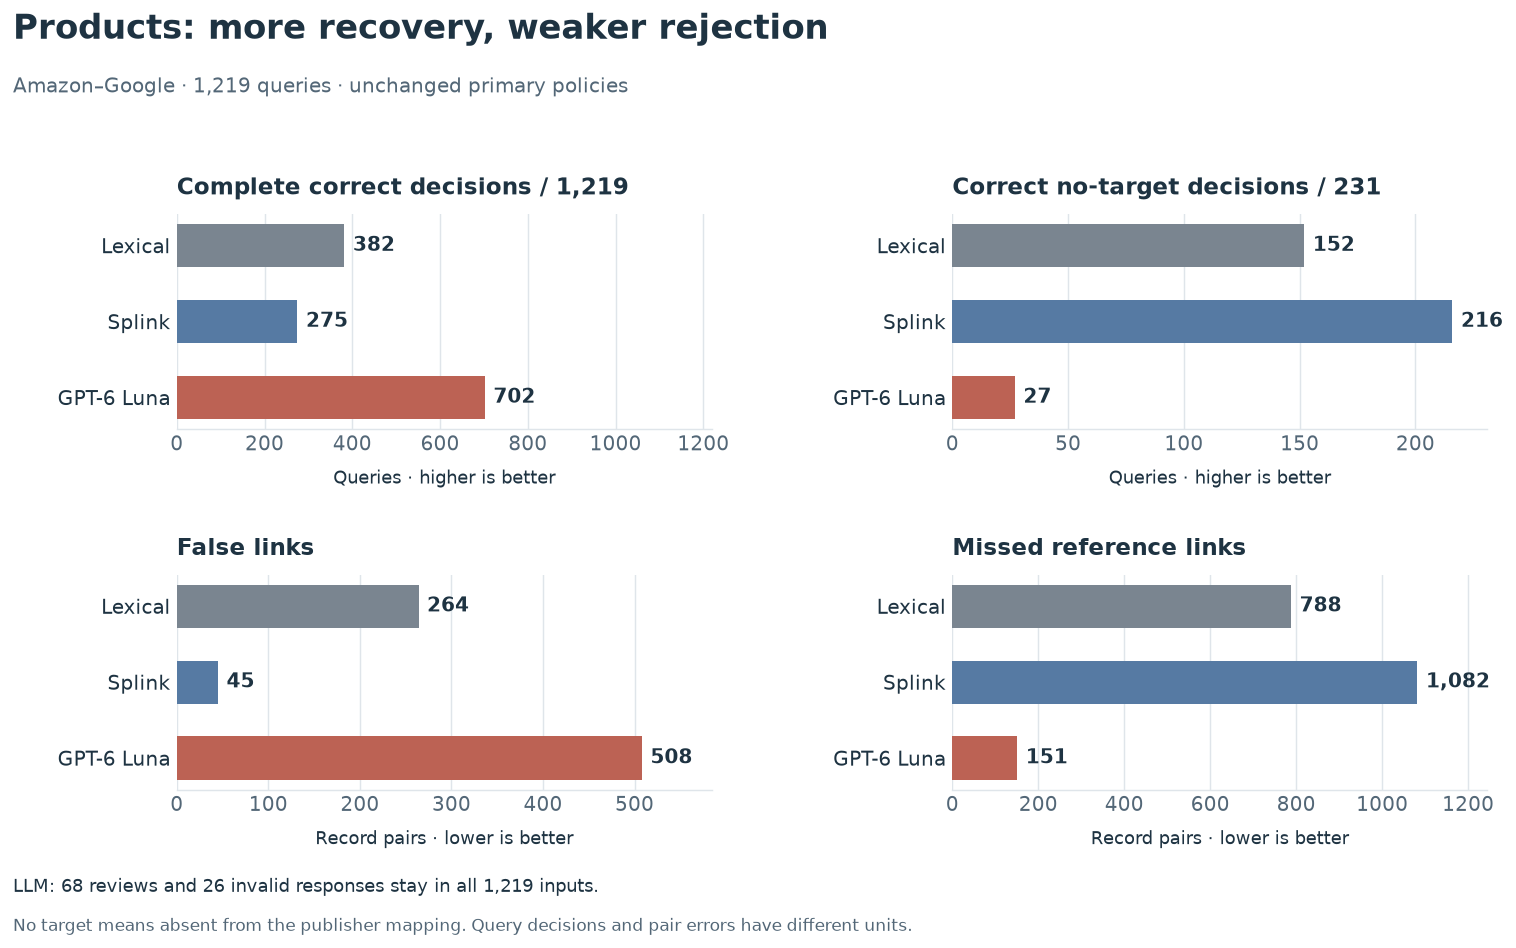

In [20]:
figure = product_tradeoff(ROOT)
display(figure, metadata={"image/png": {"width": 1000}})
plt.close(figure)

**Product decisions and edge errors, all 1,219 queries.** Semantic selection returns more exact decisions than either primary conventional policy, while producing more false links. Complete decisions count queries; false and missed links count pairs. These measures use different denominators and are shown on separate axes.

The selector makes **482 corrections and 162 regressions** against lexical: +26.3 percentage points in exact decisions, with a paired source-family 95% interval of 22.0–30.6 points. Its 702 exact decisions exceed all 64 predeclared conventional policies in the [fixed grid](nso-semantic-workflows/adversarial-2026/products/results/model-evaluation-v1/all-fixed-rule-summaries.json). The recovery gain is real against those comparisons.

The rejection failure is equally material: the selector links 173 of 231 no-counterpart queries and correctly rejects only 27, versus 152 for lexical. Of its 1,125 automatic decisions, 423 are wrong. “No counterpart” means absent from the publisher mapping; annotation omissions remain possible. Those disagreements remain errors under the unchanged reference.

<a id="product-access-chronology"></a>
The original development gate failed. A documented one-time amendment permitted this unchanged holdout. After request submission but before prediction sealing, editorial inspection exposed reference-derived metadata for two held-out records. No prompts, candidates or rules changed; all predictions were sealed before full scoring. [Protocol, access chronology and complete outcomes](nso-semantic-workflows/adversarial-2026/products/README.md#scored-comparisons).

### Candidate coverage, multiple targets and failure mechanism

Candidate retrieval retains **1,137/1,155 reference links**, and every target for **971/988 positive queries**. Missing candidates remain end-to-end misses. For 859 single-target queries, complete correct sets increase from **221 to 605** versus lexical; for the 129 multi-target queries, they increase from **9 to 70**. The no-target stratum moves in the opposite direction, **152 to 27/231**. False-assignment queries increase from **210 to 388**; this counts queries affected, whereas 264 and 508 count individual false links.

All 1,219 provider responses arrived and ended normally. The 26 invalid responses exceed the explanation-length limit in the schema; none was repaired or retried. Review and invalid outputs remain unresolved in the complete-decision denominator. Of 1,125 automatic decisions, **423 are wrong (37.6%)**.

At primary settings, conventional all-pairs and same-candidate outcomes agree. The 64 fixed conventional policies yield 224–417 exact decisions; these sensitivities shift thresholds or prior odds without refitting. No new winner is selected using the holdout. Pairing and 2,000 bootstrap resamples use 916 source families to account for shared records; the interval above is pointwise for the declared contrast, not proof of transfer to new sources.

**The operational decision depends on error costs.** In the preserved hypothetical loss grid, loss equals `false-edge weight × false links + missed links`. Semantic selection beats both primary conventional policies at weight 1. At weight 2, its loss is 1,167 versus Splink’s 1,172, a five-unit difference before review costs. At weight 5, Splink has the lowest loss of these three policies. An unresolved positive still has missed edges; an unresolved no-target query can have zero edge loss without being a correct complete decision. Human review, downstream statistical bias and staff time are unmeasured.

[All fixed policies](nso-semantic-workflows/adversarial-2026/products/results/model-evaluation-v1/all-fixed-rule-summaries.json) · [Subgroups](nso-semantic-workflows/adversarial-2026/products/results/model-evaluation-v1/subgroup-summaries.json) · [Paired intervals](nso-semantic-workflows/adversarial-2026/products/results/model-evaluation-v1/paired-family-uncertainty.json) · [Complete loss grid](nso-semantic-workflows/adversarial-2026/products/results/model-evaluation-v1/descriptive-loss-grid.json).

In [21]:
loss_rows=[]
for weight in [1,2,5]:
    row={'Assumed false-link cost / missed-link cost':weight}
    for label,key in [('Lexical','lexical_all_pairs'),('Splink','splink_all_pairs'),('Semantic','semantic_selection')]:
        outcome=_ph_summary['results'][key]
        row[label+' edge loss']=weight*outcome['false_links']+outcome['missed_links']
    loss_rows.append(row)
table(loss_rows)

Assumed false-link cost / missed-link cost,Lexical edge loss,Splink edge loss,Semantic edge loss
1,1052,1127,659
2,1316,1172,1167
5,2108,1307,2691


<a id="adversarial"></a>
## 8. Development tests and conventional-only holdouts

These results explain why some arms stopped. Development outcomes and later holdouts have different roles and are not pooled.

### Product development and the independent Abt–Buy reference

**Measured — 144 development queries against 352 catalog records.** Product models use GPT-6 Luna. Lexical matching combines word/character title and description similarity with brand, model and quantity evidence; Splink fits unlabeled observed fields, including the frozen evaluation inputs, without evaluation identities. This is transductive fitting, not a fitted-model generalization test. Semantic selection makes **112 correct decisions versus 56** for the primary lexical rule (63 corrections, seven regressions). False links increase from **8 to 20** and automatic decisions fall from **144 to 136**. The gate required eight more correct decisions, no additional false assignments and at least 137 automatic decisions; it failed. Extraction followed by Splink makes **27/144** correct decisions and also fails. The later unchanged-selector holdout was a documented one-time amendment, not a passed development gate.

| Development arm | Correct / 144 | False links | Automatic |
|---|---:|---:|---:|
| Lexical, primary threshold | 56 | 8 | 144 |
| Splink, primary policy | 21 | 0 | 144 |
| Extraction → Splink | 27 | 1 | 141 |
| Semantic selection | 112 | 20 | 136 |

The candidate union contains all targets for 124/125 positive queries. Splink's prior matters: at threshold 0.9, assumptions of 0.1, 0.5, 1 and 2 links per query give conventional counts of 26, 36, 36 and 47; extraction gives 29, 30, 35 and 46. Thus the primary extraction gain over Splink does not persist across the grid. Lexical threshold 0.5 gives 79 correct decisions with 39 false links. These are fixed descriptive policies, not retuned winners.

| Actual development query | Published target | Semantic decision | Lesson |
|---|---|---|---|
| `quake 4 (mac)` | `aspyr quake iv` | Selects target; lexical and Splink return no target | Meaning can bridge a naming variation |
| `adobe encore dvd 2.0` | No supplied counterpart | Selects an Adobe Encore DVD 2.0 listing | Reference disagreement can reflect false linkage or incomplete mappings; retain the original score |

A separate **conventional-only Abt–Buy** reference has 1,081 queries, 1,092 catalog records and 1,097 reference links. Lexical makes **341** correct sets and **13** false links; Splink makes **310** correct sets and **455** false links. Both make 1,081 automatic decisions. No semantic model ran on Abt–Buy, so it does not replicate a semantic gain. [Development grids and Abt evidence](nso-semantic-workflows/adversarial-2026/products/README.md).

### Package images: originating catalog association

**Measured — 80 development images against 96 records.** Optical character recognition (OCR) converts image text to strings. CLIP compares numerical image and text representations (embeddings). Image extraction uses GPT-5.6 Luna; the CLIP representation is frozen. Pixel extraction followed by lexical matching ties frozen CLIP at **63/80 correct**, with **eight versus 17 false links** and **71 versus 80 automatic decisions**. All four model arms fail their gates, which required at least 67 correct and 76 automatic decisions without extra false assignments. OCR-text extraction plus Splink makes 14 corrections and five regressions over OCR/Splink; pixel extraction plus Splink makes 17 and five. Neither beats the strongest conventional comparison.

| Development arm | Correct / 80 |
|---|---:|
| OCR → lexical | 61 |
| OCR → Splink | 46 |
| Frozen CLIP | 63 |
| Model on OCR → lexical | 58 |
| Model on OCR → Splink | 55 |
| Model on pixels → lexical | 63 |
| Model on pixels → Splink | 58 |

The free holdout then scores **1,000 images with conventional methods only**. Closed-view correct counts are **603 CLIP, 545 OCR/lexical and 483 OCR/Splink**. Seven failed or empty OCR observations remain in the denominators. The target is the image's originating ABO catalog record, not adjudicated physical SKU identity or product continuity in a price index.

A designed no-target view removes 200 target associations and adds 200 distractors. It also uses different frozen acceptance rules: lexical score/margin 0.30/0.03, CLIP 0.25/0.02 and Splink posterior 0.95. Consequently, changes across views mix catalog composition with policy. False no-target decisions are **231 lexical, 690 Splink and one CLIP**, while CLIP requests review on 688 queries. The complete-decision scores in the designed no-target view are **420 lexical, 276 Splink and 260 CLIP out of 1,000**. Reviews are **221, zero and 688**, respectively; the seven OCR failures remain in both OCR pipelines. The same images appear in both views; five possible cross-split perceptual-duplicate flags remain in the primary scores. [Complete image results](nso-semantic-workflows/adversarial-2026/images/results/free-test-summary.json).

### One image example and what was actually extracted

The Vedaka rice example is a selected development illustration. Pixel extraction reads “Vedaka” and “Rice” while leaving variety and quantity unknown. Correctly assigning the source catalog row does not mean the image establishes every catalog attribute. The shown image is an actual prepared photograph, not a generated control. The complete source-linked gallery preserves the other examples and their adverse decisions.

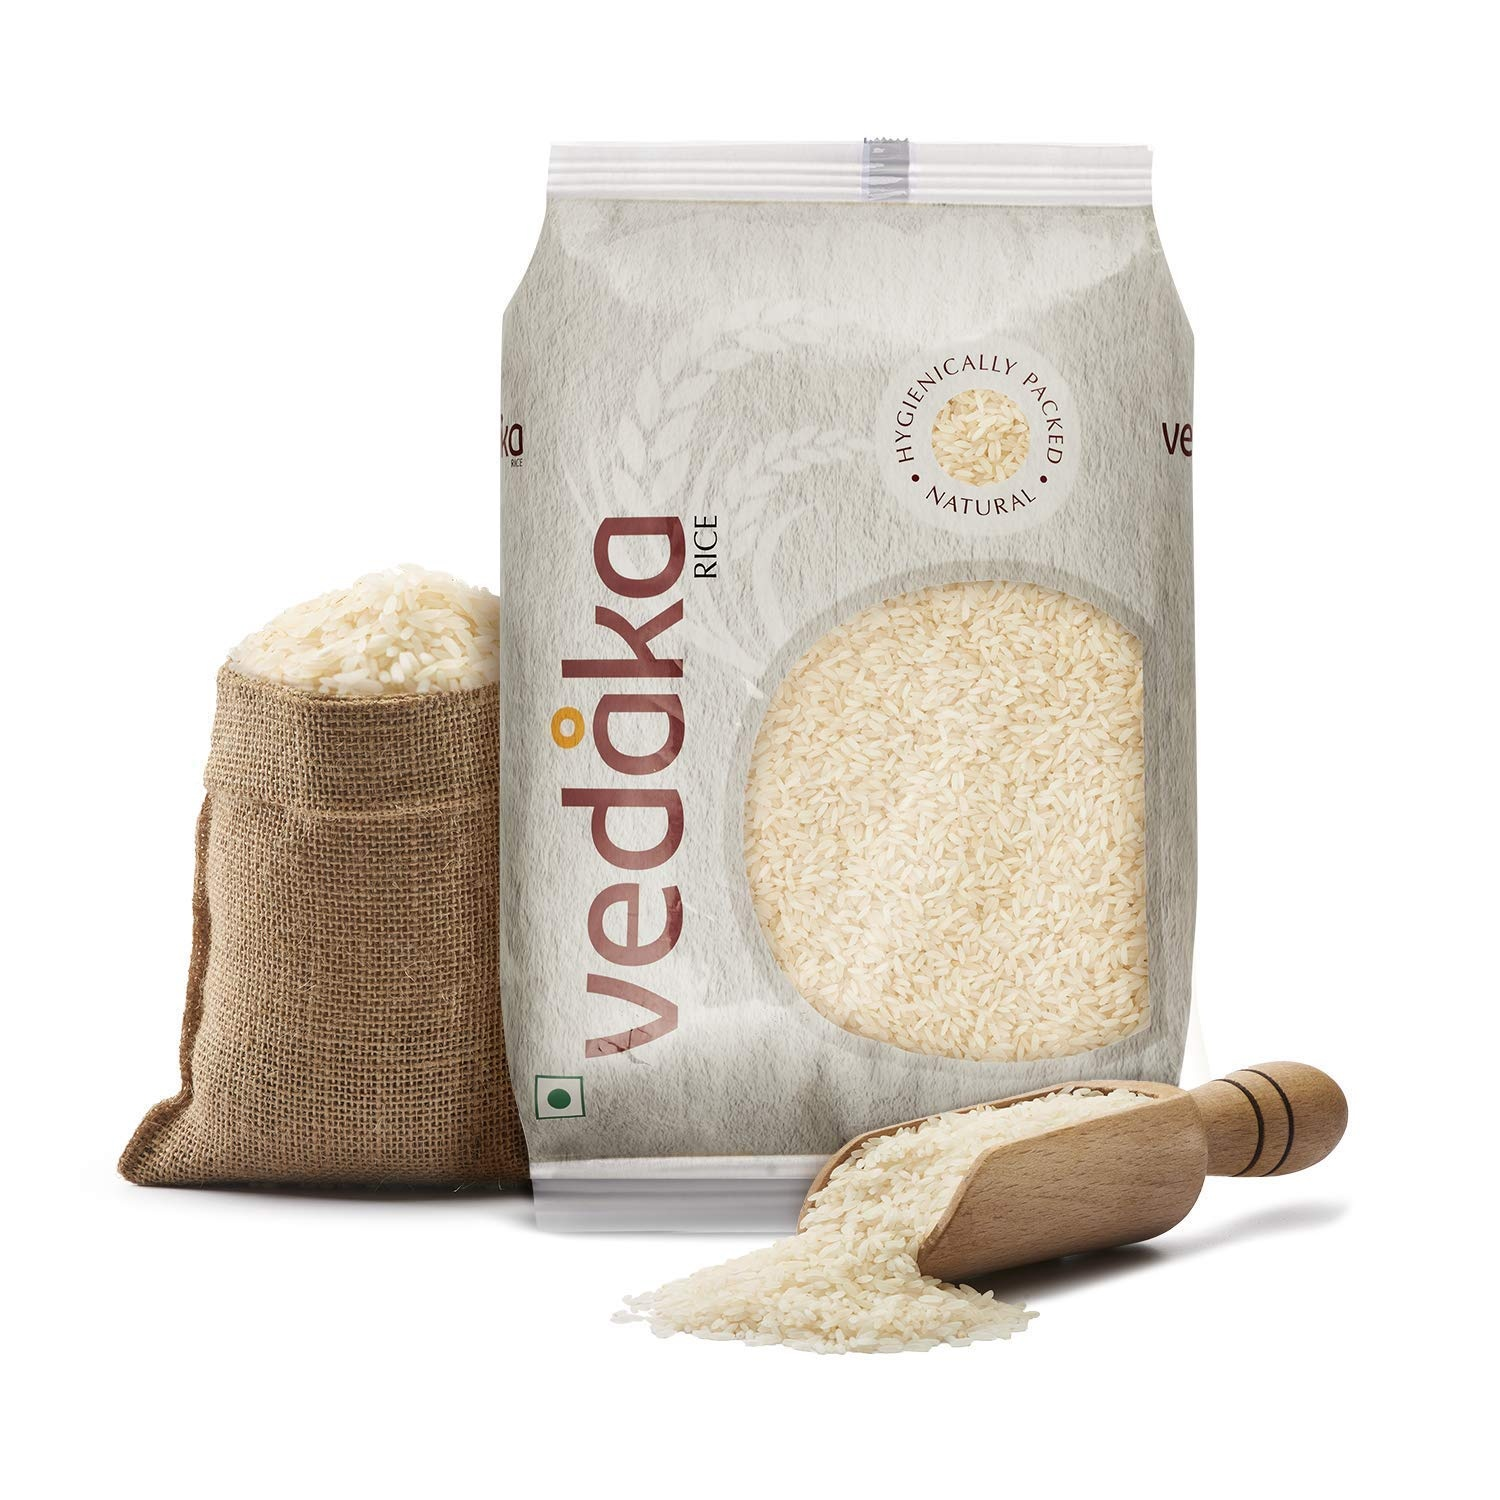

Source: [Amazon Berkeley Objects](https://registry.opendata.aws/amazon-berkeley-objects/) (Amazon), [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). Exact prepared image bytes are verified.

Extracted field,Saved value
Brand,Vedaka
Product,Rice
Variant / net quantity,Unknown / unknown


In [22]:
import dataset_showcase as gallery
showcase=gallery.load_verified()
rice=next(x for x in showcase['images']['cases'] if x['query_id']=='q_c81cc1b200047efe130d')
gallery._image(rice['asset'], 'Vedaka rice bag used in the development linkage example.',
    'Source: [Amazon Berkeley Objects](https://registry.opendata.aws/amazon-berkeley-objects/) (Amazon), '
    '[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). Exact prepared image bytes are verified.', width=260)
table([{'Extracted field':'Brand','Saved value':'Vedaka'},
       {'Extracted field':'Product','Saved value':'Rice'},
       {'Extracted field':'Variant / net quantity','Saved value':'Unknown / unknown'}])

### Organization holdout and rendered document controls

**Measured conventional methods; no new organization model evaluation.** CORDIS development uses 109 queries against 108,476 historical ROR entries. Lexical acceptance gives 60 correct automatic decisions, no false links and 49 reviews. Forced top-1 gives 77 correct and 32 false links; Splink gives 41 correct and nine false no-target decisions.

One sealed holdout contains 1,065 queries in 1,000 source groups:

| Frozen policy | Correct / 1,065 | Automatic | False links | Review |
|---|---:|---:|---:|---:|
| Lexical acceptance rule | 633 | 640 | 6 | 425 |
| Forced top-1 diagnostic | 820 | 1,065 | 245 | 0 |
| Splink EM policy | 323 | 450 | 3 | 615 |

Splink makes 124 false no-target decisions. Candidates contain **868/873 positive targets** at depth 40. Forced top-1 diagnoses ranking quality, not a suitable acceptance policy. No fitting or thresholds changed. Native affiliation sources are also prepared but unscored; these do not replace the earlier measured S2AFF test. [Organization evidence](nso-semantic-workflows/adversarial-2026/organizations/README.md).

**Prepared controls, unscored linkage.** Eighty source records are rendered in four views, including price-only views. All 640 runs of two fixed OCR modes completed. Multiple renderings do not create 320 independent records, and OCR completion is not a linkage result. Price-only evidence should preserve uncertainty rather than define a true no-match. [Document controls](nso-semantic-workflows/adversarial-2026/controls/README.md) · [All selected source records and decisions](nso-semantic-workflows/adversarial-2026/dataset-showcase.json).

<a id="agentic"></a>
## 9. What the native tool-use demonstration establishes

**Illustrative fixture, measured execution — three invented office returns.** The task asks for the September 2026 completion fraction using each office's latest approved return. Sources include a superseded revision, a newer draft that must be excluded and counts expressed in thousands. Eligible cases equal issued minus ineligible; pooled completion equals total completed divided by total eligible. This is not an official survey response-rate estimator.

`read_return` supplies rows and local definitions. The model selects revisions and units; `calculate_rates` performs Decimal arithmetic. A separate reference check validates every selected source, normalized count and citation, with the reference withheld from prompts. A calculator can otherwise compute a wrong plan exactly—as the numerical-query errors already showed.

```python
result = make_corpus().agent(
    TASK, ops=["map", "reduce"], tools=make_tools(), plan="auto",
    strategies={"map": "per_unit"}, max_parallelism=3, max_steps=4,
    lm=ledger, completer_factory=ledger.completer_factory,
)
```

The recorded execution chooses all sources and counts correctly and obtains **1,130/1,600 = 70.625%**. Averaging office percentages would give 68.33%, a different statistic. The trace includes one planning, nine map and two reduce calls, with three source reads and four calculator calls. LOTUS 1.2.4's native usage excludes planning, so the audited adapter records it. Its `reduce_strategy` is unused; this reducer is one agent over the findings.

In [23]:
from agentic_demo import load_demo, run_live as run_agentic_live
agentic_path = run_agentic_live(budget_usd=0.10) if RUN_AGENTIC_LIVE else None
agentic_snapshot = load_demo(agentic_path)
v = agentic_snapshot['validation']
display(pd.DataFrame([{'Completed': v['completed_total'], 'Eligible': v['eligible_total'],
                      'Pooled completion (%)': v['pooled_completion_percent'],
                      'Model calls': v['model_calls'], 'Tool calls': v['tool_calls']}]))

,Completed,Eligible,Pooled completion (%),Model calls,Tool calls
0,1130,1600,70.625,12,7


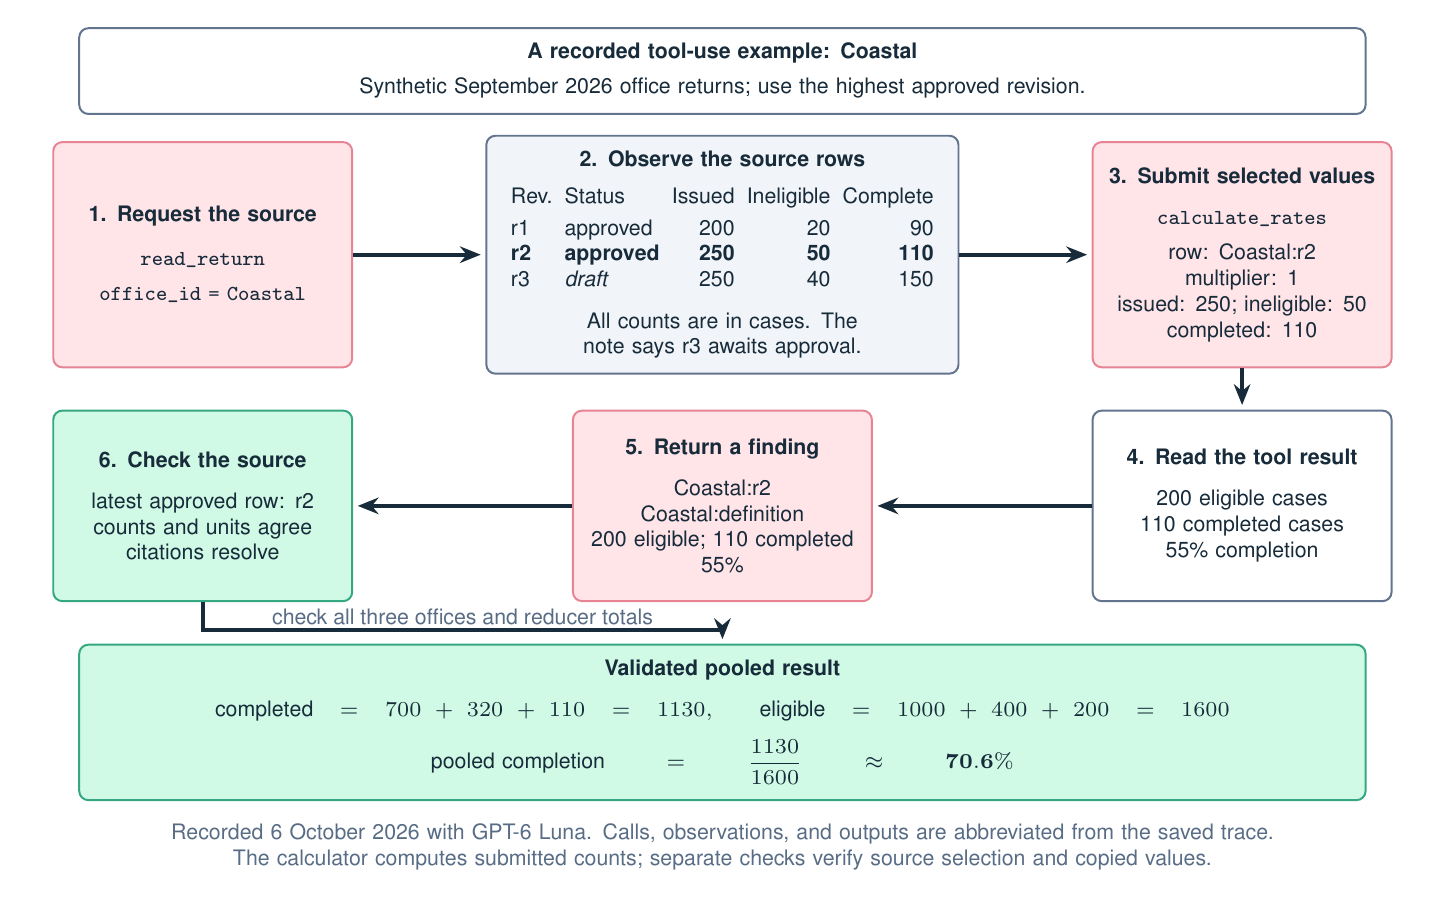

[Full-size PDF](record-linkage-tutorial/diagrams/10-agentic-evidence-loop.pdf)

In [24]:
diagram("10-agentic-evidence-loop")

**Recorded source-to-calculation path.** The diagram abbreviates actual tool calls from the synthetic Coastal return. It shows the approved revision, submitted counts, calculator output and independent checks before pooling all three offices.

This demonstrates an inspectable path from source interpretation to exact calculation. One successful run on invented data does not measure reliability across formats or an advantage over a purpose-built parser. A useful later comparison would hold tools, documents and correctness standard fixed and measure whether interpretation reduces adaptation effort. [Fixture](record-linkage-tutorial/data/agentic-office-returns.json) · [Full saved plan and trace](record-linkage-tutorial/results/agentic-office-returns-gpt-6-luna.json).

<a id="costs"></a>
## 10. Costs, invalid outputs and evidence preservation

These are recorded token-price estimates at the study dates, not invoices, staff costs, hardware costs or measured savings. Reservations provide budget headroom and are not spending. Calls, pairs, records and questions are different units.

In [25]:
usage=snapshot['usage_summary']
pilot_cost=report['ledger_snapshot']
agent_cost=agentic_snapshot['validation']
text_cost=text_benchmark.get('cost', {})
table([
 {'Run':'FEBRL GPT-6 Luna','Model requests':'225','Estimated US$':f"{usage['uncached_price_estimate_usd']:.5f}"},
 {'Run':'BioDEX + FEVER, two current models','Model requests':'152 decisions','Estimated US$':'0.0343 (rounded)'},
 {'Run':'Three-office native agent','Model requests':agent_cost['model_calls'],'Estimated US$':f"{agent_cost['uncached_price_estimate_usd']:.7f}"},
 {'Run':'Initial affiliation/coding/statistics pilot, development + test','Model requests':pilot_cost['attempted_calls'],'Estimated US$':f"{pilot_cost['estimated_token_price_usd']:.7f}"},
 {'Run':'Product/image development','Model requests':800,'Estimated US$':'0.1491891'},
 {'Run':'Amended product holdout','Model requests':_ph_execution['attempted_requests'],'Estimated US$':f"{float(_ph_execution['nominal_token_price_usd']):.8f}"},
])

Run,Model requests,Estimated US$
FEBRL GPT-6 Luna,225,0.00641
"BioDEX + FEVER, two current models",152 decisions,0.0343 (rounded)
Three-office native agent,12,0.0015939
"Initial affiliation/coding/statistics pilot, development + test",952,0.2577545
Product/image development,800,0.1491891
Amended product holdout,1219,0.11984625


The initial pilot reserves about **USD 0.93**; follow-up development reserves **USD 0.98534** and the product holdout **USD 0.96350**. Reservation and nominal usage-price conventions differ across the recorded request modes; retain their separate fields rather than treating them as invoices. Shared catalog extraction is counted once. The FEBRL model uses **57,300 input and 1,350 output tokens**; the three-office run uses **10,109 and 1,166**, taking about **13.4 seconds**. Timing from one environment is not a throughput benchmark.

| Stage | Preserved invalid-output evidence |
|---|---|
| Initial pilot | Zero provider/schema failures; eight task-invalid outputs across development and test: four affiliation, three coding, one numerical plan |
| Product extraction development | 33/496 invalid record extractions: 29 schema rejections and four unsupported source quotations; three are query records and the remainder affect catalog evidence |
| Image extraction development | 8/160 invalid outputs: six schema rejections and two length-terminated invalid responses |
| Product holdout | 26/1,219 invalid responses from explanation-length limits; 68 separate reviews |

No repair or retry was applied to those follow-up failures. A received parseable response can still be task-invalid. A failure, a review request and a valid no-target decision are different outcomes; unresolved queries stay in denominators. The strict Boolean wrapper for native joins likewise refuses to silently turn malformed answers into nonmatches.

The evidence retains source versions, labels, candidates, requests, prompts, raw responses, seals, hashes, failures and all outcomes. Pre-model corrections remain documented: one cook vignette was clarified, occupation retrieval included all nonempty duties, missing outputs remained in denominators and three CPI-difference units were corrected to index points. These were not changes selected to improve test predictions.

[Pilot ledger and paired outcomes](nso-semantic-workflows/results/analysis/README.md) · [Follow-up accounting](nso-semantic-workflows/adversarial-2026/README.md) · [Native model snapshots](record-linkage-tutorial/README.md#inspect-the-evidence).

### Earlier model runs remain historical comparisons

The 2026 model comparisons supply the main narrative. Historical GPT-4 results are replayed below; failed-attempt snapshots remain in the supporting evidence so a model change cannot erase an adverse result. Their prompts, dates and model versions remain part of each snapshot; they are not additional independent datasets.

In [26]:
historical_spec=run_spec(semantic_left,semantic_right,PREDICATE,'gpt-4.1-mini-2025-04-14')
historical_snapshot=load_snapshot(SUPPORT/'results/lotus-febrl4.json',historical_spec)
historical_scores=metrics(evaluation.is_match,pd.Series([p['decision'] for p in historical_snapshot['pairs']]))
table([{'Historical FEBRL model':'GPT-4.1 mini','True links':int(historical_scores['TP']),
        'False links':int(historical_scores['FP']),'Missed links':int(historical_scores['FN']),
        'Recorded estimated US$':'0.0241'}])
historical_text=benchmark_tables(text_data,model_group='historical')['metrics']
historical_text=historical_text[historical_text.method.str.contains('gpt-',case=False)]
display(historical_text[['task','method','pairs','TP','FP','FN','TN']].set_index(['task','method']))

Historical FEBRL model,True links,False links,Missed links,Recorded estimated US$
GPT-4.1 mini,8,0,2,0.0241


pairs  TP  FP  FN  TN
task   method                                        
biodex gpt-4.1-nano-2025-04-14     64   3  11   8  42
       gpt-4o-mini-2024-07-18      64   6  10   5  43
fever  gpt-4.1-nano-2025-04-14     12   6   1   0   5
       gpt-4o-mini-2024-07-18      12   6   0   0   6

<a id="lessons"></a>
## 11. Candidate coverage and independent audit

The following calculations preserve lessons from the methodological work. They are **illustrative**, with no new empirical gain implied.

### Candidate coverage determines the ceiling

If 80 of 100 true links enter the candidates and the matcher recovers 60, candidate recall is 80%, conditional matcher recall is 75%, and end-to-end recall is **60%**. For a fixed pipeline with accepted pairs contained in the candidate set,

`end-to-end recall = candidate recall × recall among candidates`.

The catalog and product experiments show why these denominators matter. If another stage adds pairs, include them in the candidate set being evaluated. Discovery examples chosen because they look difficult cannot estimate population error.

A representative independent sample of accepted links with zero errors gives a one-sided 95% binomial upper error bound of about **1% after 300 reviews**, or **0.1% after 3,000**. Shared entities, unequal sampling weights and incomplete adjudication change that calculation. For recall at very low pair prevalence, uniform pair sampling is inefficient: with 100 million true links among 10 quadrillion possible pairs, a million random pairs contain only 0.01 expected true links. [Record-centered evaluation](https://arxiv.org/html/2404.05622v1).

In [27]:
display(recall_example().style.format({"recall": format_percent, "numerator": "{:,.0f}", "denominator": "{:,.0f}"}))
audit_sizes = np.array([300, 3000])
display(pd.DataFrame({"reviewed accepted links": audit_sizes,
    "false links observed": 0,
    "95% upper false-link fraction": 1 - 0.05 ** (1 / audit_sizes)}).style.format({"95% upper false-link fraction": format_percent,
    "reviewed accepted links": "{:,.0f}", "false links observed": "{:,.0f}"}))
expected_matches = 1_000_000 * (100_000_000 / 100_000_000**2)
display(pd.Series({"expected true links in 1M uniform pairs": expected_matches}).to_frame("value").style.format("{:.2f}"))

,numerator,denominator,recall
measure,,,
Candidate recall,80,100,80%
Recall conditional on candidacy,60,80,75%
End-to-end recall,60,100,60%


,reviewed accepted links,false links observed,95% upper false-link fraction
0,300,0,1%
1,"3,000",0,0.1%


,value
expected true links in 1M uniform pairs,0.01


<a id="clustering"></a>
## 12. Clustering: discover reusable repairs and learn a cheaper similarity

**Research proposals with deterministic examples; no clustering improvement has been measured.** Two questions follow from the linkage results. Can groups of observed failure patterns help discover corrections that transfer? Can selected LLM judgments teach a cheaper representation for identity matching? Each needs a comparison that isolates its contribution.

| Object being grouped | What membership means | What must be checked |
|---|---|---|
| Diagnostic group | Pairs share observed disagreement, missingness or ambiguity | Whether the suspected mechanism and repair apply to members and counterexamples |
| Entity cluster | Records are asserted to describe the same entity | False merges, splits and the correctness of implied relationships |
| Repair applicability region | An executable correction applies to these records or pairs | Corrections and introduced errors on new entities, including outside the region |

### 12.1 Turn a repeated diagnostic pattern into a tested repair

A diagnostic group uses observed field agreements, missingness, parsing flags or competing candidates; its pairs may describe unrelated entities. It differs from an entity cluster, which asserts that records refer to one entity. Without reviewed labels or identifiable model assumptions, observed grouping cannot establish an error rate. Similar-looking cases also need not share a cause. A repair needs a source-supported mechanism, an executable intervention and validation on other entities. Applicability can overlap: repair 1 may benefit cases A and B, while repair 2 benefits B and C. That does not make A and C interchangeable. The calculation below defines benefit as reduction in zero–one loss: one unit for a corrected pair, zero for no change and minus one for an introduced error.

A fair experiment should compare random, uncertainty/diversity and diagnostic-group selection with the same features, seed labels, repair library, update rule and budget. Cross each acquired label set with ordinary updating and repair-plus-update to separate selection value from repair value. This research is unrun; the small FEBRL baseline has no errors to repair.

Without labels, a group can reveal repeated formats or disagreement patterns. Faithful reviewed labels or an identifiable model are needed to estimate its linkage error rate. Fuzzy membership describes geometry under a chosen distance; it is not an error probability. Inspect several members, boundaries and counterexamples before applying a shared change.

For example, source documentation can establish that `13/04/1988` and `04/13/1988` use different date formats. A source-specific parser can then recover the same date while preserving both original strings. Ambiguous strings without a known format remain unresolved. The group earns credit only if it helps find or delimit that correction more efficiently than other review strategies.

[Supporting review](../research/error-guided-record-linkage/README.md) · [Controlled experimental protocol](../research/error-guided-record-linkage/experiment-protocol.md).


In [28]:
repair_cases, repair_benefits = repair_benefit_example()
display(repair_cases)
display(repair_benefits.rename(columns=lambda c: c + " benefit"))

,truth,baseline,repair 1,repair 2
case,,,,
A,True,False,True,False
B,True,False,True,True
C,True,False,False,True
D,False,False,True,False


,repair 1 benefit,repair 2 benefit
case,,
A,1,0
B,1,1
C,0,1
D,-1,0


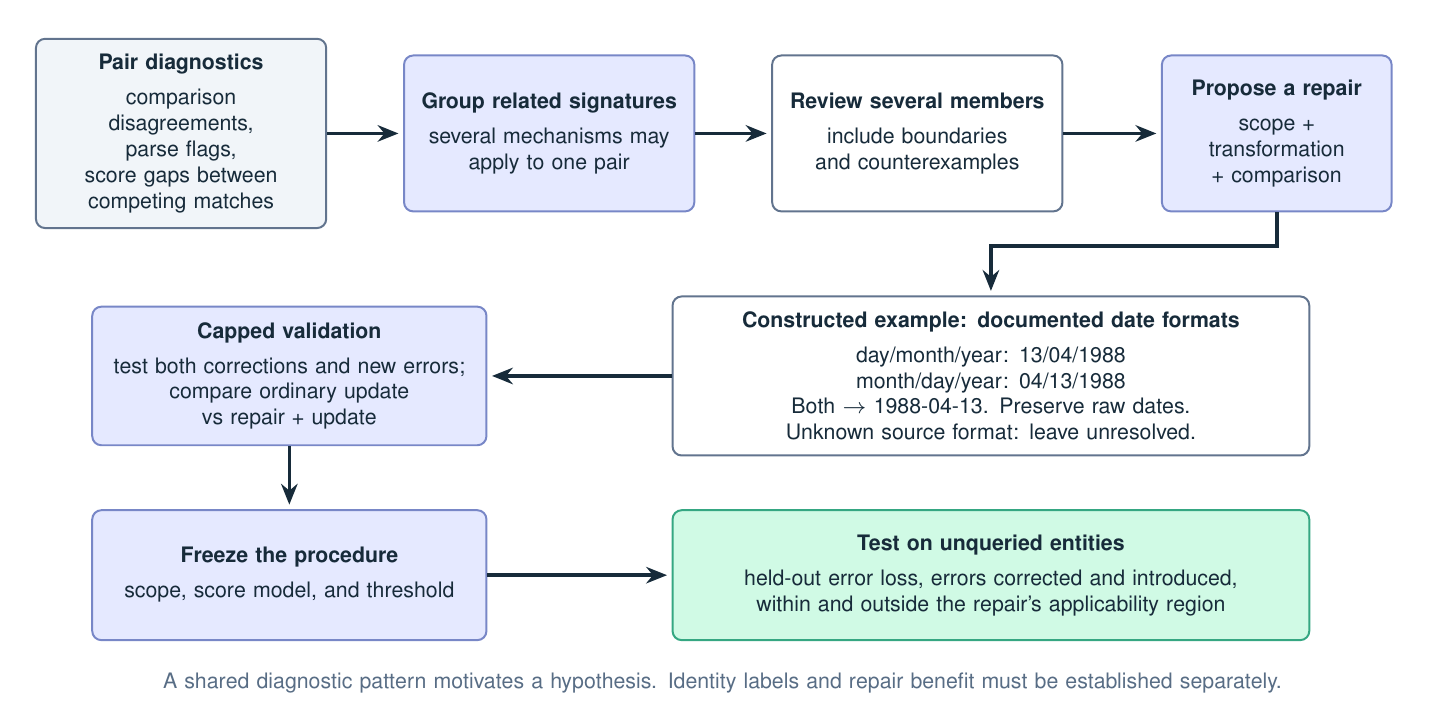

[Full-size PDF](record-linkage-tutorial/diagrams/06-diagnosis-repair.pdf)

In [29]:
diagram("06-diagnosis-repair")

**Proposed diagnosis-to-repair loop.** Observed patterns select investigations. Source evidence supports a bounded correction; separate entities test its benefit. This diagram and the date example illustrate the mechanism, not a measured correction.

### 12.2 Isolate selection value from repair value

The proposed experiment crosses four review selectors with two update branches:

| Budgeted review selector | Ordinary model update | Same repair library + same update |
|---|---|---|
| Stratified random review | Reference acquisition policy | Reference repair opportunity |
| Uncertainty + noncluster diversity | Tests uncertainty and coverage | Tests repairs without cluster selection |
| Diagnostic-cluster coverage | Tests label selection through grouping | Tests the proposed repair contribution |
| Supervised error-risk selection | Tests direct prediction of baseline errors | Tests repair selection after learning risk |

Across selectors within each update branch, diagnostic features, seed labels, candidate pairs, validation access and resource ceilings are shared; only acquired pairs differ. Every selector in the repair branch receives the same repair library and update rule. Comparing branches isolates the added repair opportunity. This four-by-two design separates grouping from repair capability.

Fit diagnostic transforms and groups on development data. Charge every acquired, validation and calibration label. Freeze the operating loss and procedure before evaluating untouched entities. Report corrected and introduced errors, unresolved cases, candidate recall and review costs. A useful result is lower held-out linkage loss under the same budget; compact geometric clusters alone do not establish that result.

The current 225-pair person slice has no Splink errors to repair. Stage zero therefore checks development headroom under a capable baseline before implementing this experiment. Target loss, label budget and the allowed repair family remain decisions for the new study. [Complete staged protocol](../research/error-guided-record-linkage/experiment-protocol.md).


### Selective semantic evidence needs conditional calibration

Let $S$ be the baseline information, $D$ the LLM decision and $R$ the event that the pair is routed for review. The incremental evidence is

$$\operatorname{odds}(Y=1\mid S,D,R)=\operatorname{odds}(Y=1\mid S,R)
\frac{P(D\mid Y=1,S,R)}{P(D\mid Y=0,S,R)}.$$

The likelihood ratio is conditional on information and routing already used. A regularized joint model on separate calibration data is one candidate comparison to a pooled error-rate update; small subgroup fits can themselves be unstable. The dependence illustration in Section 2 explains the risk. No new hybrid has been fitted here.

### 12.3 Use selected LLM judgments to learn reusable identity evidence

An LLM teacher can label selected pairs; a cheaper student can learn from them. An affinity is a score for a specified relation and becomes a match probability only after calibration for a defined population. Topic similarity, repeated prompt agreement and identity are different targets. A triplet identity query also needs “neither,” ties and insufficient-evidence options.

Published work motivates reusable representations and supervised entity matching, but the complete proposed teacher–student system has not run here. Test information value by holding queried development pairs, student inputs and tuning effort fixed while changing the label source. Then test deployment value across extraction, student prediction and selective direct review at equal total budgets, including acquisition, retraining and refresh. Split whole entities; public benchmark reshuffling does not undo prior label exposure.

Pair accuracy is also insufficient for clustering. Accepting all 2,450 true within-entity pair edges and connecting the two otherwise correct 50-record entities with one erroneous edge produces **2,500 false co-clustered pairs**, even though the initial pair precision is **99.96%**. Every merge of groups of sizes $n_1,n_2$ asserts $n_1n_2$ cross-group relationships. Evaluate entity structure as well as pair decisions.

The scalable hypothesis is to learn a reusable embedding or inexpensive pair scorer from a budgeted set of judgments, then freeze its decision and graph rules. Direct LLM calls remain available for selected ambiguous cases. [ClusterLLM](https://aclanthology.org/2023.emnlp-main.858/) demonstrates LLM-guided text clustering; its task results motivate testing this identity-specific transfer rather than establish it here.

| Controlled comparison | Quantity held fixed | Evidence needed for a gain |
|---|---|---|
| Human/reference labels versus LLM teacher labels | Queried development pairs, student inputs and tuning effort | Better identity decisions on unseen entities; count teacher errors |
| Recordwise extraction versus a learned scorer versus selective direct review | Permitted source evidence and total resource ceiling | End-to-end error, review burden, acquisition and refresh costs |
| Pair decisions versus final entity clusters | Frozen candidate set, scores and graph rule | Merge/split and pairwise cluster errors; preserve candidate misses |

Topic similarity and identity should use separate evaluation labels. A direct pairwise LLM affinity can be asymmetric or inconsistent across triplets; a clustering procedure needs an explicit way to handle that uncertainty. The learned scorer’s calibration and final entity structure must be checked independently.


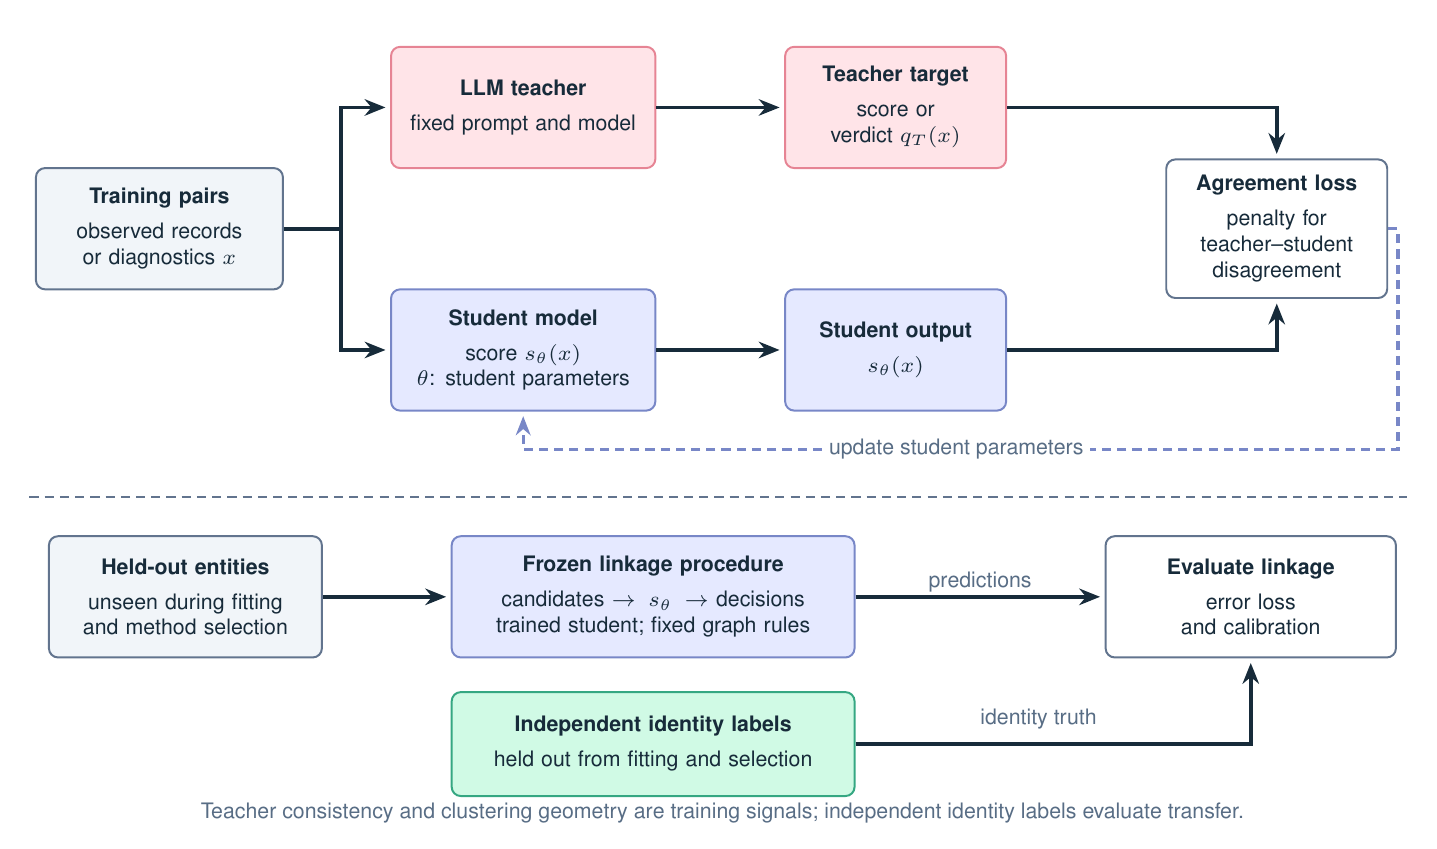

[Full-size PDF](record-linkage-tutorial/diagrams/07-teacher-student.pdf)

In [30]:
diagram("07-teacher-student")

**Proposed reusable supervision.** The LLM labels selected development pairs; the student learns a cheaper score. Independent held-out identity labels evaluate transfer. Teacher agreement is a training target, while linkage correctness is the evaluation target.

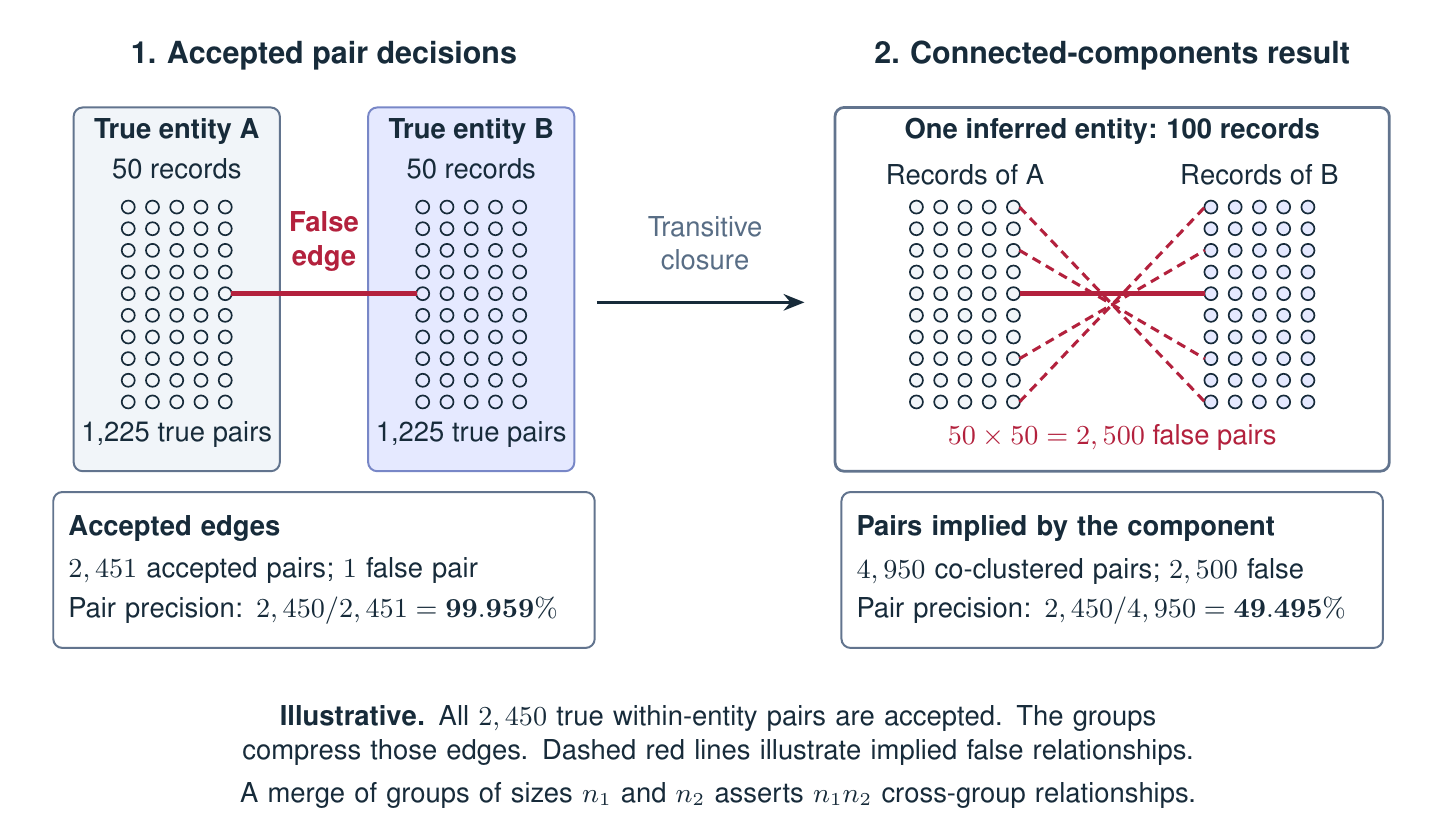

[Full-size PDF](record-linkage-tutorial/diagrams/15-clustering-bridge.pdf)

In [31]:
diagram("15-clustering-bridge")

**Constructed bridge example.** Each true entity has 50 records, with all within-entity edges accepted. One false edge gives 2,450/2,451 = 99.96% direct edge precision. Connected-component closure then asserts all 4,950 pairs in the merged group, including 2,500 false relationships, reducing pairwise co-clustering precision to 49.49%. The calculation illustrates error propagation; it is not a measured clustering result.

In [32]:
bridge_results = bridge_example(size_a=50, size_b=50)
display(bridge_results.style.format({"precision": format_percent, "recall": format_percent,
    "predicted matching pairs": "{:,.0f}", "false matching pairs": "{:,.0f}"}))

,predicted matching pairs,false matching pairs,precision,recall
stage,,,,
Accepted edges,"2,451",1,99.96%,100%
After connected components,"4,950","2,500",49.5%,100%


<a id="scale"></a>
## 13. Scale arithmetic and research context

### A sparse candidate set still leaves substantial work

**Illustrative — 100 million records on each side, 20 candidates per left record.** Full comparison has 10 quadrillion pairs; sparse retrieval still leaves two billion. At 24 bytes per retained edge the raw payload is 48 GB, before indexes and overhead. A 384-dimensional float16 vector for every record in both sources adds 153.6 GB. The calculation below preserves the other workload assumptions.

Cache recordwise extraction by source and model version; count candidate generation, indexes, storage, model requests and refresh costs. Recursive subdivision can approach quadratic work when branches keep cross-comparing. Neither the toy arithmetic nor the inspected small studies establish a measured 100-million-by-100-million system.

In [33]:
workload = scale_example(rows_per_source=100_000_000, candidates_per_left=20,
                         dimensions=384, teacher_queries=5_000)
def readable_quantity(row):
    if row.unit == "bytes":
        unit, divisor = ("PB", 10**15) if row.value >= 10**15 else ("GB", 10**9)
        return f"{row.value / divisor:,.1f} {unit}"
    return f"{row.value:,} {row.unit}"

display(workload.assign(quantity_display=workload.apply(readable_quantity, axis=1))
        [["quantity_display"]].rename(columns={"quantity_display": "work or storage"}))

,work or storage
quantity,
Cross-file pairs,"10,000,000,000,000,000 pairs"
Retained candidate pairs,"2,000,000,000 pairs"
Dense affinity (float32),40.0 PB
Both files' vectors (float16),153.6 GB
Candidate edge payload (24 bytes/edge),48.0 GB
32 float32 diagnostics per candidate,256.0 GB
Direct review of 0.01% of candidates,"200,000 pairs"
All-record extraction input (500 tokens/record),"100,000,000,000 tokens"
All-record extraction output (50 tokens/record),"10,000,000,000 tokens"


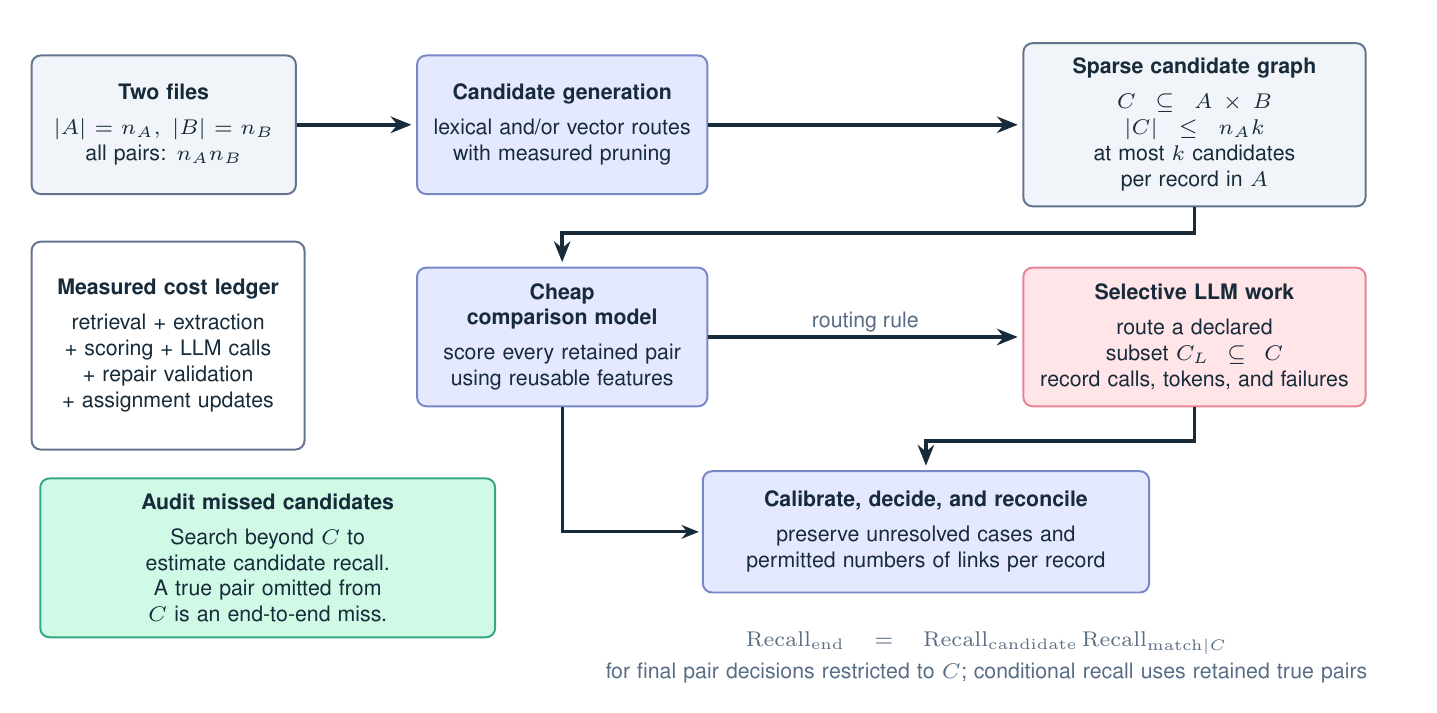

[Full-size PDF](record-linkage-tutorial/diagrams/08-sparse-scale.pdf)

In [34]:
diagram("08-sparse-scale")

### Research context retained from the literature review

The established ingredients are probabilistic linkage, candidate retrieval, semantic operators, active learning and learned representations. The strongest demonstrated contribution of this notebook is their **comparative evidence and failure analysis**; a novel repair, distillation or deployment method remains a research question.

| Research direction | Relevant primary sources | Question still requiring this project's evidence |
|---|---|---|
| Semantic execution and reusable features | [LOTUS](https://www.vldb.org/pvldb/vol18/p4171-patel.pdf), [FDJ](https://arxiv.org/html/2512.05399v1) | Can an optimized implementation meet both reference fidelity and independent task accuracy at lower total cost? |
| LLM supervision of representations | [ClusterLLM](https://aclanthology.org/2023.emnlp-main.858/), [Few-Shot Clustering](https://aclanthology.org/2024.tacl-1.18/), [INSTRUCTOR](https://aclanthology.org/2023.findings-acl.71/) | Does learned semantic structure transfer to unseen-entity identity, rather than only topic clusters? |
| Budgeted judgments and identity clustering | [Cequel](https://arxiv.org/html/2504.15640v2), [LLM-CER](https://arxiv.org/html/2506.02509v1), [LLM-generated constraints](https://ojs.aaai.org/index.php/AAAI/article/view/39379) | Do savings survive token counts, selection compute and downstream graph errors? |
| Entity-matching distillation | [DistillER](https://arxiv.org/html/2602.05452v1), [June 2026 study](https://arxiv.org/html/2606.28823v1) | Does a cheaper student preserve useful accuracy on the intended relation and source population? |
| Diagnosis, repair and audit | [Ather](https://doi.org/10.1177/18747655261422068), [record-centered evaluation](https://arxiv.org/html/2404.05622v1), [research protocol](../research/error-guided-record-linkage/README.md) | Does diagnosis add held-out benefit beyond the same repairs and labels without grouping? |

These are methodological leads, not completed experiments in this report. Optional exercises can test understanding: reconstruct the worked match score; change the false-link cost in the product table; explain the candidate-recall denominator; identify why one false graph edge causes many wrong entity relationships.

<a id="next"></a>
## 14. Government text, NSO relevance and the next decision

There is a documented statistical use for text interpretation. ONS's ClassifAI retrieves candidate industry codes and asks an LLM to select a code or return “uncodable”; ONS reports introducing it for business-description coding in late 2025. Statistics Canada reports research on extracting structured data from unstructured PDFs using fine-tuning and retrieval-assisted extraction. These precedents motivate the problem; they do not establish that these agencies use LOTUS or validate this report's pipeline. [ONS method](https://datasciencecampus.ons.gov.uk/classifai-exploring-the-use-of-large-language-models-llms-to-assign-free-text-to-commonly-used-classifications/) · [ONS implementation context](https://www.ons.gov.uk/businessindustryandtrade/business/activitysizeandlocation/methodologies/ukbusinessactivitysizeandlocationqmi) · [Statistics Canada research](https://www150.statcan.gc.ca/n1/pub/12-206-x/2025001/02-eng.htm).

The results support investigating **source-grounded contextual selection after capable retrieval**, with acceptance and review tested explicitly. Affiliation matching provides the best real-text evidence here; coding provides the closest statistical workflow with synthetic-label limitations. The product result makes the rejection problem visible. Historical products and package images remain supporting method studies rather than evidence of an operational administrative-text workflow.

### Actual legal text, prepared but unscored

Three LePaRD examples are preserved with source records. A later court opinion's argument context links to a quoted passage from an earlier opinion. The objects are different documents; the relation is use of that passage in an argument. The source supplies extracted quotation links, not a complete relevance judgment for every other precedent.

The example below displays bounded verbatim excerpts; the saved source retains full fields. For a context-only retrieval test, source identities and the observed quotation belong in the evaluation view, not as answer-revealing query inputs. No model score exists for this packet. [Full records, provenance and CC BY-NC-SA 4.0 licence](nso-semantic-workflows/government-documents/README.md).

In [35]:
government = json.loads((ROOT / 'government-documents/samples.json').read_text())
g = government['examples'][0]['raw_row']
# Display bounded verbatim excerpts; the linked source preserves every field.
table([
    {'Side': 'Query document', 'Source': g['dest_name'], 'Excerpt': g['destination_context'].strip()[:460] + '…'},
    {'Side': 'Observed linked passage', 'Source': g['source_name'], 'Excerpt': g['quote'][:460] + '…'},
])

Side,Source,Excerpt
Query document,"United States v. Associated Credit Bureaus, Inc.","It does not prohibit the members from using other organizations as sources of credit information.\nIf the 1933 decree were equally susceptible to the interpretations the government is now urging, the Court would not accept those interpretations. ACB’s “coupon rules” have been in existence since the establishment of ACB’s parent organization in 1906 and the wording of those rules has not been substantially changed since that time. The consent order of 1953 r…"
Observed linked passage,United States v. Atlantic Refining Co.,"We merely hold that where the language of a consent decree in its normal meaning supports an interpretation; where that interpretation has been adhered to over many years by all the parties, including those government officials who drew up and administered the decree from the start (citation omitted); and where the trial court concludes that this interpretation is in fact the one the parties intended, we will not reject it simply because another reading mi…"


### Finite next actions

**Recommendation: take the affiliation selection result into one defined statistical workflow, after checking the reference relation and acceptance requirement.** The trained comparison is complete and the gain remains. The next uncertainty is transfer to the target workflow and its acceptance policy. An official S2AFF comparison remains necessary before claiming an advantage over that specialist. Products establish a recovery/rejection trade-off, coding remains synthetic, and the other completed branches do not justify new model calls now.

| Order | To-do | Deliverable and decision gate |
|---|---|---|
| 1 | Name one statistical user, output dataset, relation and unit | One study card with acceptable false-link and review burden; select the use case before collecting a larger corpus |
| 2 | Check source access and reference meaning on a capped packet | Inspect ordinary cases, difficult cases and no-target cases; distinguish aliases, parent/child entities, alternative labels and simultaneous affiliations |
| 3 | Establish what capable cheap methods already solve | Keep real identifiers; compare identifier extraction, field matching and trained retrieval/reranking on the same permitted text; hiding IDs is a separate capability test |
| 4 | Make one go/no-go decision | Continue only if trustworthy labels and a useful residual text relation survive; otherwise preserve the stopping reason |
| 5 | Freeze a genuinely new evaluation | Group development/holdout splits, candidate generation, baselines, thresholds, error/review limits and total budget before inference; keep new labels independent of the chosen predictions |
| 6 | Test value at the required quality level | Compare correctly recovered relations at the declared error allowance; count failures and review; measure staff time or downstream statistical effects only if claiming those benefits |

A charity-return recipient → charity-register entry is an administrative option. A registered trial/protocol → results publication is another candidate mechanism study, potentially supporting research-output coverage; its relevance to an actual NSO product remains unestablished. Select one relation, rather than starting both. **If** the trial relation is chosen, the previously proposed audit is capped at 12 families and 36 pair inspections, with ordinary sampled cases separate from deliberate challenges. A registry reference list supplies leads, not exhaustive negative labels; an unlisted article needs adjudication before it is labeled unrelated.

These are proposed next-study actions. The immediate research question is whether source-grounded interpretation improves a defined statistical data product **after capable extraction and retrieval**, at a useful error and review level. Further numerical-agent tuning, image-model holdout calls and billion-scale deployment work have no demonstrated priority from these results.

<a id="reproduce"></a>
## 15. Reproduce the report and interpret the measures

This is the single reader notebook. The two support directories hold code and immutable evidence, not alternative reports. Default execution fits the small supervised Splink reference locally, verifies the saved EM artifacts, validates saved model responses and displays recorded NSO results plus the trained affiliation comparison. The new comparison replays saved predictions; retraining from the pinned full registry is a separate command in its support README. It requires no API key, model call or download.

From the repository root, in the tested environment:

```bash
.venv/bin/python LLM_basics/nso-semantic-workflows/run_notebook.py --html semantic-joins-report.html
```

The runner uses the launching interpreter through a temporary kernel. The recorded environment is Python **3.11.15 on macOS**, Splink **5.0.0** and LOTUS **1.2.4**; the statistics execution contract also pins recorded dependency versions. Windows is unsupported by the POSIX-locking live-request machinery, and other platforms are not claimed tested. [Environment and native replay](record-linkage-tutorial/README.md) · [NSO protocols and verification](nso-semantic-workflows/README.md).

Code inputs are hidden in the HTML reading copy and remain inspectable in the notebook. All three live flags default to false. Repeating model inference is a separate opt-in action with new timestamped evidence; this report's narrative describes the preserved October runs.

| Term or measure | Meaning in this report |
|---|---|
| True/false positive (TP/FP) | Accepted pair present/absent in the specified reference |
| False negative (FN), missed link | Reference pair not accepted, including targets in unresolved positive queries |
| True negative (TN) | Rejected pair absent from the reference, for a defined pair universe |
| Precision / recall | True accepted pairs divided by all accepted pairs / all reference pairs |
| Complete product decision | Every reference target, no extras, and a valid resolved status; reviews and failures are unresolved |
| Valid affiliation set | Selected set agrees with the annotated set and passes task validation; may still carry a review flag |
| Correct coding decision | Correct unique code or required review, reported separately above |
| NIL / no target | A resolved assertion that the reference has no counterpart; absence from a public mapping may be incomplete truth |
| Candidate recall | Fraction of reference links retained for the decision stage |
| Automatic coverage | Fraction returned as valid resolved decisions without review; correctness is assessed separately |
| Pointwise interval | Uncertainty for one declared comparison, under its stated sampling/resampling assumptions |
| Source-grounded evidence | A recoverable source span or field supporting an output; a valid schema alone does not establish truth |

All denominators remain task-specific. Repeated organizations, source families and synthetic variants limit independent-trial interpretations. Synthetic controls, demonstrations, observed benchmark counts and research proposals are kept distinct throughout the report.

The recorded model studies were performed on 6–8 October 2026. The trained affiliation comparison was completed on 9 October without new model API calls. Prices and versions describe those runs.